# Feature Analysis & Correlation Visualizer

Generates diagnostic plots for deepfake feature analysis across a 260-dimensional feature pipeline.

**Output plots:**
- `01_class_distributions.png` — KDE (Kernel Density Estimation) histograms for top 12 discriminative features
- `02_top_features_boxplot.png` — Side-by-side boxplots for top 20 features
- `03_correlation_heatmap.png` — Pearson correlation matrix for top 40 features
- `04_feature_group_means.png` — Mean activation per descriptor family
- `05_azimuthal_fft.png` — Radial spectrum mean ± σ with |Δ| overlay
- `06_pca_variance.png` — Scree plot + PC1 vs PC2 scatter
- `07_tsne_projection.png` — 2D t-SNE embedding with KDE contours
- `08_feature_importance.png` — Top 30 features by Random Forest Gini importance
- `09_radar.png` — Group-level activation radar chart

In [ ]:
%matplotlib inline
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120

---
## Part 1 — Imports & Configuration

In [8]:
import os
import glob
import random
import warnings
from pathlib import Path

import numpy as np
import cv2
from PIL import Image
from scipy.stats import skew, kurtosis, ttest_ind
from scipy.fftpack import dct
from skimage.feature import local_binary_pattern, graycomatrix, graycoprops
import mahotas

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch
from matplotlib.colors import LinearSegmentedColormap

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.ensemble import RandomForestClassifier
from scipy.stats import gaussian_kde

warnings.filterwarnings("ignore")
print("✓ Imports complete")






✓ Imports complete


In [9]:
# ── User Configuration ────────────────────────────────────────────────────────
# Edit these paths before running

DATASET_ROOT  = "C:/Users/gaura/Downloads/deepfake_pipeline/datasets/"
TRAIN_DATASET = "train"
MAX_PER_CLASS = 300
OUTPUT_DIR    = "./MediaLab"
SEED          = 42

OUT_DIR = Path(OUTPUT_DIR)
OUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"Output directory: {OUT_DIR}")

Output directory: MediaLab


---
## Part 2 — Colour Palette & Plot Style

In [10]:
# ── Colour palette ────────────────────────────────────────────────────────────
REAL_COLOR  = "#00C9A7"   # teal-green
FAKE_COLOR  = "#FF6B6B"   # coral-red
BG_COLOR    = "#0D1117"   # near-black
PANEL_COLOR = "#161B22"   # dark panel
GRID_COLOR  = "#21262D"   # subtle grid
TEXT_COLOR  = "#E6EDF3"   # off-white
ACCENT      = "#58A6FF"   # blue accent
MUTED       = "#8B949E"   # muted text

REAL_CMAP = LinearSegmentedColormap.from_list("real", ["#003D32", REAL_COLOR])
FAKE_CMAP = LinearSegmentedColormap.from_list("fake", ["#4D0000", FAKE_COLOR])
DIV_CMAP  = LinearSegmentedColormap.from_list(
    "div", ["#FF6B6B", "#0D1117", "#00C9A7"])

def apply_dark_style():
    plt.rcParams.update({
        "figure.facecolor":  BG_COLOR,
        "axes.facecolor":    PANEL_COLOR,
        "axes.edgecolor":    GRID_COLOR,
        "axes.labelcolor":   TEXT_COLOR,
        "axes.titlecolor":   TEXT_COLOR,
        "axes.grid":         True,
        "grid.color":        GRID_COLOR,
        "grid.linewidth":    0.6,
        "xtick.color":       MUTED,
        "ytick.color":       MUTED,
        "text.color":        TEXT_COLOR,
        "legend.facecolor":  PANEL_COLOR,
        "legend.edgecolor":  GRID_COLOR,
        "font.family":       "monospace",
        "figure.dpi":        120,
    })

print("✓ Style configured")

✓ Style configured


---
## Part 3 — Feature Groups & Names

In [11]:
# ── Feature group definitions ─────────────────────────────────────────────────
# Each entry: group_name -> (start_index, end_index)  [end exclusive]
# Total: 260 dimensions

FEATURE_GROUPS = {
    "Color":         (0,   12),
    "GLCM":          (12,  14),
    "LBP":           (14,  24),
    "Gabor":         (24,  32),
    "Edge":          (32,  35),
    "Frequency":     (35,  37),
    "Hu Moments":    (37,  44),
    "Haralick":      (44,  57),
    "LDCP":          (57,  73),
    "DCCM":          (73,  79),
    "Azimuthal FFT": (79, 260),
}

GROUP_COLORS = {
    "Color":         "#FF9F43",
    "GLCM":          "#48DBFB",
    "LBP":           "#FF6B6B",
    "Gabor":         "#A29BFE",
    "Edge":          "#FD79A8",
    "Frequency":     "#00CEC9",
    "Hu Moments":    "#FDCB6E",
    "Haralick":      "#6C5CE7",
    "LDCP":          "#00B894",
    "DCCM":          "#E17055",
    "Azimuthal FFT": "#74B9FF",
}


def make_feature_names():
    """Build a human-readable name for every one of the 260 features."""
    names = []
    # Color (12)
    for ch in ["r", "g", "b"]:
        for s in ["mean", "std", "skew", "kurtosis"]:
            names.append(f"color_{ch}_{s}")
    # GLCM (2)
    names += ["glcm_contrast", "glcm_homogeneity"]
    # LBP (10)
    names += [f"lbp_bin_{i}" for i in range(10)]
    # Gabor (8)
    for t in [0, 1]:
        for s in [1, 3]:
            names += [f"gabor_t{t}_s{s}_mean", f"gabor_t{t}_s{s}_std"]
    # Edge (3)
    names += ["edge_sobel_mean", "edge_sobel_std", "edge_canny_density"]
    # Frequency (2)
    names += ["freq_fft_mean", "freq_dct_top16"]
    # Hu Moments (7)
    names += [f"hu_{i}" for i in range(7)]
    # Haralick (13)
    names += [f"haralick_{i}" for i in range(13)]
    # LDCP (16)
    names += [f"ldcp_bin_{i}" for i in range(16)]
    # DCCM (6)
    names += [f"dccm_{p}" for p in ["contrast","dissimilarity","homogeneity","energy","correlation","ASM"]]
    # Azimuthal FFT (181)
    names += [f"azimuthal_{i}" for i in range(181)]
    return names


FEATURE_NAMES = make_feature_names()
print(f"✓ Feature names built — total: {len(FEATURE_NAMES)} dimensions")

# Quick sanity check
for g, (s, e) in FEATURE_GROUPS.items():
    print(f"  {g:16s}  dims {s:>3}–{e:>3}  ({e-s} features)")

✓ Feature names built — total: 260 dimensions
  Color             dims   0– 12  (12 features)
  GLCM              dims  12– 14  (2 features)
  LBP               dims  14– 24  (10 features)
  Gabor             dims  24– 32  (8 features)
  Edge              dims  32– 35  (3 features)
  Frequency         dims  35– 37  (2 features)
  Hu Moments        dims  37– 44  (7 features)
  Haralick          dims  44– 57  (13 features)
  LDCP              dims  57– 73  (16 features)
  DCCM              dims  73– 79  (6 features)
  Azimuthal FFT     dims  79–260  (181 features)


---
## Part 4 — Feature Extractor

In [12]:
# ── Kirsch directional masks (used by LDCP & DCCM) ───────────────────────────
KIRSCH_MASKS = [
    np.array([[ 5,  5,  5], [-3,  0, -3], [-3, -3, -3]], dtype=np.float32),
    np.array([[-3,  5,  5], [-3,  0,  5], [-3, -3, -3]], dtype=np.float32),
    np.array([[-3, -3,  5], [-3,  0,  5], [-3,  5,  5]], dtype=np.float32),
    np.array([[-3, -3, -3], [-3,  0,  5], [-3,  5,  5]], dtype=np.float32),
    np.array([[-3, -3, -3], [-3,  0, -3], [ 5,  5,  5]], dtype=np.float32),
    np.array([[-3, -3, -3], [ 5,  0, -3], [ 5,  5, -3]], dtype=np.float32),
    np.array([[ 5, -3, -3], [ 5,  0, -3], [ 5, -3, -3]], dtype=np.float32),
    np.array([[ 5,  5, -3], [ 5,  0, -3], [-3, -3, -3]], dtype=np.float32),
]


def ldcp_features(gray):
    """Local Directional Co-occurrence Pattern (16 dims).
    Each pixel is assigned the index of the Kirsch mask with the strongest response.
    Result is histogrammed into 16 bins.
    """
    gray = gray.astype(np.float32)
    responses  = np.stack([cv2.filter2D(gray, -1, k) for k in KIRSCH_MASKS], axis=-1)
    ldcp_code  = np.argmax(responses, axis=-1)
    hist, _    = np.histogram(ldcp_code.ravel(), bins=16, range=(0, 16), density=True)
    return hist.tolist()


def dccm_features(gray):
    """Directional Co-occurrence of Compressed Maps (6 dims).
    GLCM computed on the LDCP direction map (values 0–7) instead of raw grayscale.
    """
    gray      = gray.astype(np.float32)
    ldcp_code = np.argmax(
        np.stack([cv2.filter2D(gray, -1, k) for k in KIRSCH_MASKS], axis=-1), axis=-1
    ).astype(np.uint8)
    glcm  = graycomatrix(ldcp_code, distances=[1],
                         angles=[0, np.pi/4, np.pi/2, 3*np.pi/4],
                         levels=8, symmetric=True, normed=True)
    props = ["contrast", "dissimilarity", "homogeneity", "energy", "correlation", "ASM"]
    return [float(graycoprops(glcm, p).mean()) for p in props]


def azimuthalAverage(image, center=None):
    """Radially average a 2D image into a 1D power spectrum."""
    y, x = np.indices(image.shape)
    if center is None:
        center = np.array([(x.max()-x.min())/2.0, (y.max()-y.min())/2.0])
    r    = np.sqrt((x-center[0])**2 + (y-center[1])**2).astype(np.int32)
    tbin = np.bincount(r.ravel(), image.ravel())
    nr   = np.bincount(r.ravel())
    return tbin / np.maximum(nr, 1)


def central_crop(image, crop_size=256):
    """Return the centre crop_size × crop_size patch, padding if needed."""
    h, w = image.shape
    if h < crop_size or w < crop_size:
        ph = max((crop_size - h) // 2 + 1, 0)
        pw = max((crop_size - w) // 2 + 1, 0)
        image = np.pad(image, ((ph, ph), (pw, pw)), mode='constant')
        h, w  = image.shape
    sy = (h - crop_size) // 2
    sx = (w - crop_size) // 2
    return image[sy:sy+crop_size, sx:sx+crop_size]


def extract_features(pil_img):
    """Extract the full 260-dimensional feature vector from a PIL image."""
    img  = np.array(pil_img.convert("RGB"))
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    v    = []

    # Color statistics (12)
    r, g, b = cv2.split(img)
    for chan in [r, g, b]:
        flat = chan.reshape(-1).astype(np.float64)
        v += [float(np.mean(flat)), float(np.std(flat)),
              float(skew(flat)),    float(kurtosis(flat))]

    # GLCM (2)
    gray_u8 = cv2.normalize(gray, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    glcm    = graycomatrix(gray_u8, distances=[1, 2], angles=[0, np.pi/4],
                           levels=256, symmetric=True, normed=True)
    v += [float(graycoprops(glcm, "contrast").mean()),
          float(graycoprops(glcm, "homogeneity").mean())]

    # LBP histogram (10)
    lbp  = local_binary_pattern(gray, P=8, R=1, method="uniform")
    hist, _ = np.histogram(lbp.ravel(), bins=np.arange(0, 11), density=True)
    v.extend(hist.tolist())

    # Gabor filters (8)
    for theta in [0, np.pi/4]:
        for sigma in [1, 3]:
            kernel = cv2.getGaborKernel((21, 21), sigma, theta, 10.0, 0.5, 0, ktype=cv2.CV_32F)
            fimg   = cv2.filter2D(gray, cv2.CV_32F, kernel)
            v += [float(np.mean(fimg)), float(np.std(fimg))]

    # Edge features (3)
    sx    = cv2.Sobel(gray, cv2.CV_32F, 1, 0, ksize=5)
    sy_   = cv2.Sobel(gray, cv2.CV_32F, 0, 1, ksize=5)
    mag   = np.sqrt(sx**2 + sy_**2)
    canny = cv2.Canny(gray, 100, 200)
    v += [float(np.mean(mag)), float(np.std(mag)), float(np.mean(canny > 0))]

    # Frequency features (2)
    fshift = np.fft.fftshift(np.fft.fft2(gray))
    v.append(float(np.mean(np.abs(fshift))))
    dct_c  = dct(dct(gray.astype(np.float32), axis=0, norm="ortho"), axis=1, norm="ortho")
    v.append(float(np.mean(dct_c[:16, :16])))

    # Hu Moments (7)
    _, bw = cv2.threshold(gray, 0, 255, cv2.THRESH_OTSU | cv2.THRESH_BINARY)
    hu    = cv2.HuMoments(cv2.moments(bw)).flatten()
    v.extend(hu.tolist())

    # Haralick (13)
    v.extend(mahotas.features.haralick(gray_u8).mean(axis=0).tolist())

    # LDCP (16) and DCCM (6)
    v.extend(ldcp_features(gray))
    v.extend(dccm_features(gray))

    # Azimuthal FFT (181)
    crop     = central_crop(gray, 256)
    mag_spec = 20 * np.log(np.abs(np.fft.fftshift(np.fft.fft2(crop))) + 1e-8)
    az       = azimuthalAverage(mag_spec)[:181]
    if len(az) < 181:
        az = np.pad(az, (0, 181 - len(az)), mode='constant')
    v.extend(az.tolist())

    return np.array(v, dtype=np.float32)


print("✓ Feature extractor defined — output size:", 260, "dims")

✓ Feature extractor defined — output size: 260 dims


---
## Part 5 — Data Loading & Featurization

In [13]:
IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tiff", ".webp"}

def collect_images(folder):
    """Recursively find all image files under `folder`."""
    paths = []
    for ext in IMAGE_EXTS:
        paths += glob.glob(str(Path(folder) / "**" / f"*{ext}"),      recursive=True)
        paths += glob.glob(str(Path(folder) / "**" / f"*{ext.upper()}"), recursive=True)
    return sorted(set(paths))


def load_and_featurize(dataset_dir, max_per_class=300, seed=42):
    """Walk dataset_dir looking for 0_real/ and 1_fake/ subdirs,
    sample up to max_per_class images each, and extract features.
    Returns X (N, 260) and y (N,) arrays.
    """
    rng = random.Random(seed)
    real_paths, fake_paths = [], []

    for dirpath, _, _ in os.walk(dataset_dir):
        dn = os.path.basename(dirpath)
        if dn == "0_real":   real_paths.extend(collect_images(dirpath))
        elif dn == "1_fake": fake_paths.extend(collect_images(dirpath))

    real_paths = list(set(real_paths))
    fake_paths = list(set(fake_paths))

    if len(real_paths) > max_per_class:
        real_paths = rng.sample(real_paths, max_per_class)
    if len(fake_paths) > max_per_class:
        fake_paths = rng.sample(fake_paths, max_per_class)

    print(f"  Real: {len(real_paths)}  Fake: {len(fake_paths)}")

    X, y = [], []
    all_paths  = real_paths + fake_paths
    all_labels = [0] * len(real_paths) + [1] * len(fake_paths)

    for i, (p, lbl) in enumerate(zip(all_paths, all_labels)):
        print(f"  Extracting features {i+1}/{len(all_paths)}", end="\r")
        try:
            feat = extract_features(Image.open(p).convert("RGB"))
            if not (np.any(np.isnan(feat)) or np.any(np.isinf(feat))):
                X.append(feat)
                y.append(lbl)
        except Exception as e:
            pass

    print()
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.int32)


print("✓ Data loading functions defined")

✓ Data loading functions defined


In [14]:
# ── Load or extract features ──────────────────────────────────────────────────
# If a cached .npz exists it will be loaded directly to save time.

cache_path = OUT_DIR / "features" / "train_progan.npz"
dataset_path = Path(DATASET_ROOT) / TRAIN_DATASET

print(f"Dataset path : {dataset_path}")
print(f"Cache path   : {cache_path}\n")

if cache_path.exists():
    print("✓ Found cached features — loading from disk …")
    data = np.load(cache_path)
    X, y = data["X"], data["y"]
else:
    print("Extracting features (this may take a few minutes) …")
    X, y = load_and_featurize(str(dataset_path),
                               max_per_class=MAX_PER_CLASS,
                               seed=SEED)
    np.savez(str(cache_path), X=X, y=y)
    print(f"✓ Saved features to {cache_path}")

print(f"\nFeature matrix : {X.shape}")
print(f"Real={np.sum(y==0)}  Fake={np.sum(y==1)}")

Dataset path : C:\Users\gaura\Downloads\deepfake_pipeline\datasets\train
Cache path   : MediaLab\features\train_progan.npz

✓ Found cached features — loading from disk …

Feature matrix : (8000, 260)
Real=4000  Fake=4000


---
## Part 6 — Plot 01: Class Distributions

KDE-style histograms for the **top 12 most discriminative features** ranked by t-test p-value.

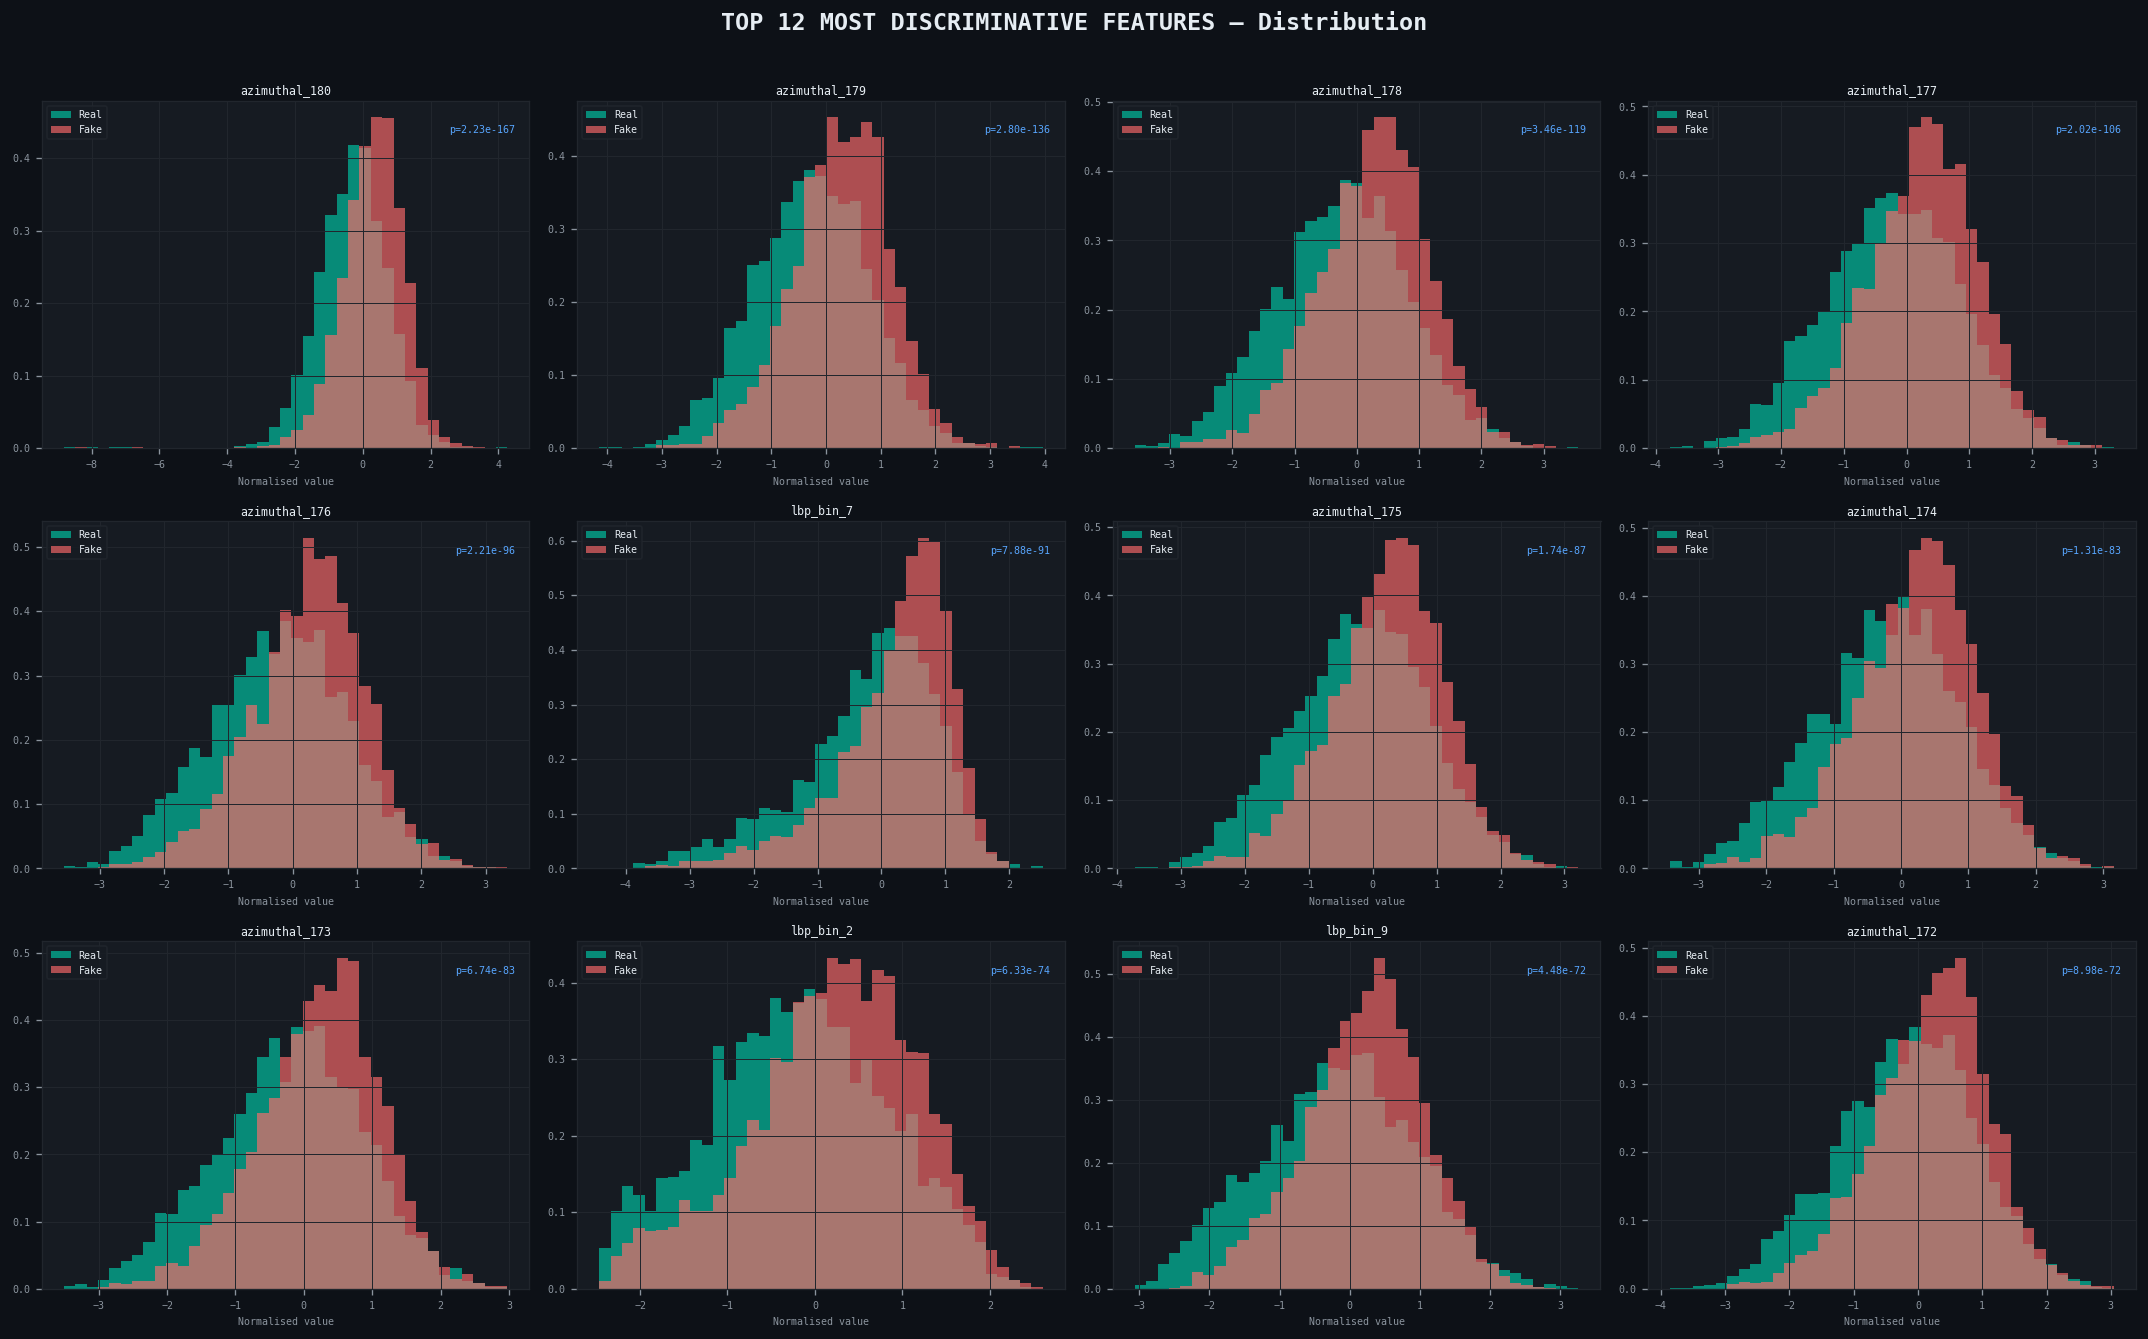

✓  MediaLab\plots\01_class_distributions.png


In [15]:
def plot_class_distributions(X, y, out_path):
    apply_dark_style()
    scaler = StandardScaler()
    Xs     = scaler.fit_transform(X)
    X_real = Xs[y == 0]
    X_fake = Xs[y == 1]

    # Pick top 12 by t-test p-value
    pvals = []
    for i in range(X.shape[1]):
        _, p = ttest_ind(X_real[:, i], X_fake[:, i], equal_var=False)
        pvals.append(p)
    top12 = np.argsort(pvals)[:12]

    fig, axes = plt.subplots(3, 4, figsize=(18, 11))
    fig.suptitle("TOP 12 MOST DISCRIMINATIVE FEATURES — Distribution",
                 fontsize=14, color=TEXT_COLOR, y=1.01, fontweight="bold")
    fig.patch.set_facecolor(BG_COLOR)

    for ax, idx in zip(axes.flat, top12):
        name = FEATURE_NAMES[idx] if idx < len(FEATURE_NAMES) else f"feat_{idx}"
        vr   = X_real[:, idx]
        vf   = X_fake[:, idx]
        bins = np.linspace(min(vr.min(), vf.min()), max(vr.max(), vf.max()), 40)
        ax.hist(vr, bins=bins, alpha=0.65, color=REAL_COLOR, label="Real",  density=True)
        ax.hist(vf, bins=bins, alpha=0.65, color=FAKE_COLOR, label="Fake",  density=True)
        ax.set_title(name, fontsize=7, color=TEXT_COLOR, pad=4)
        ax.set_xlabel("Normalised value", fontsize=6, color=MUTED)
        ax.tick_params(labelsize=6)
        ax.legend(fontsize=6)
        ax.text(0.97, 0.93, f"p={pvals[idx]:.2e}", transform=ax.transAxes,
                ha="right", va="top", fontsize=6, color=ACCENT)

    plt.tight_layout()
    plt.savefig(out_path, bbox_inches="tight", facecolor=BG_COLOR)
    plt.show()
    plt.close()
    print(f"✓  {out_path}")


plot_class_distributions(X, y, OUT_DIR / "plots" / "01_class_distributions.png")


---
## Part 7 — Plot 02: Box Plots

Side-by-side boxplots for the **top 20 most discriminative features**.

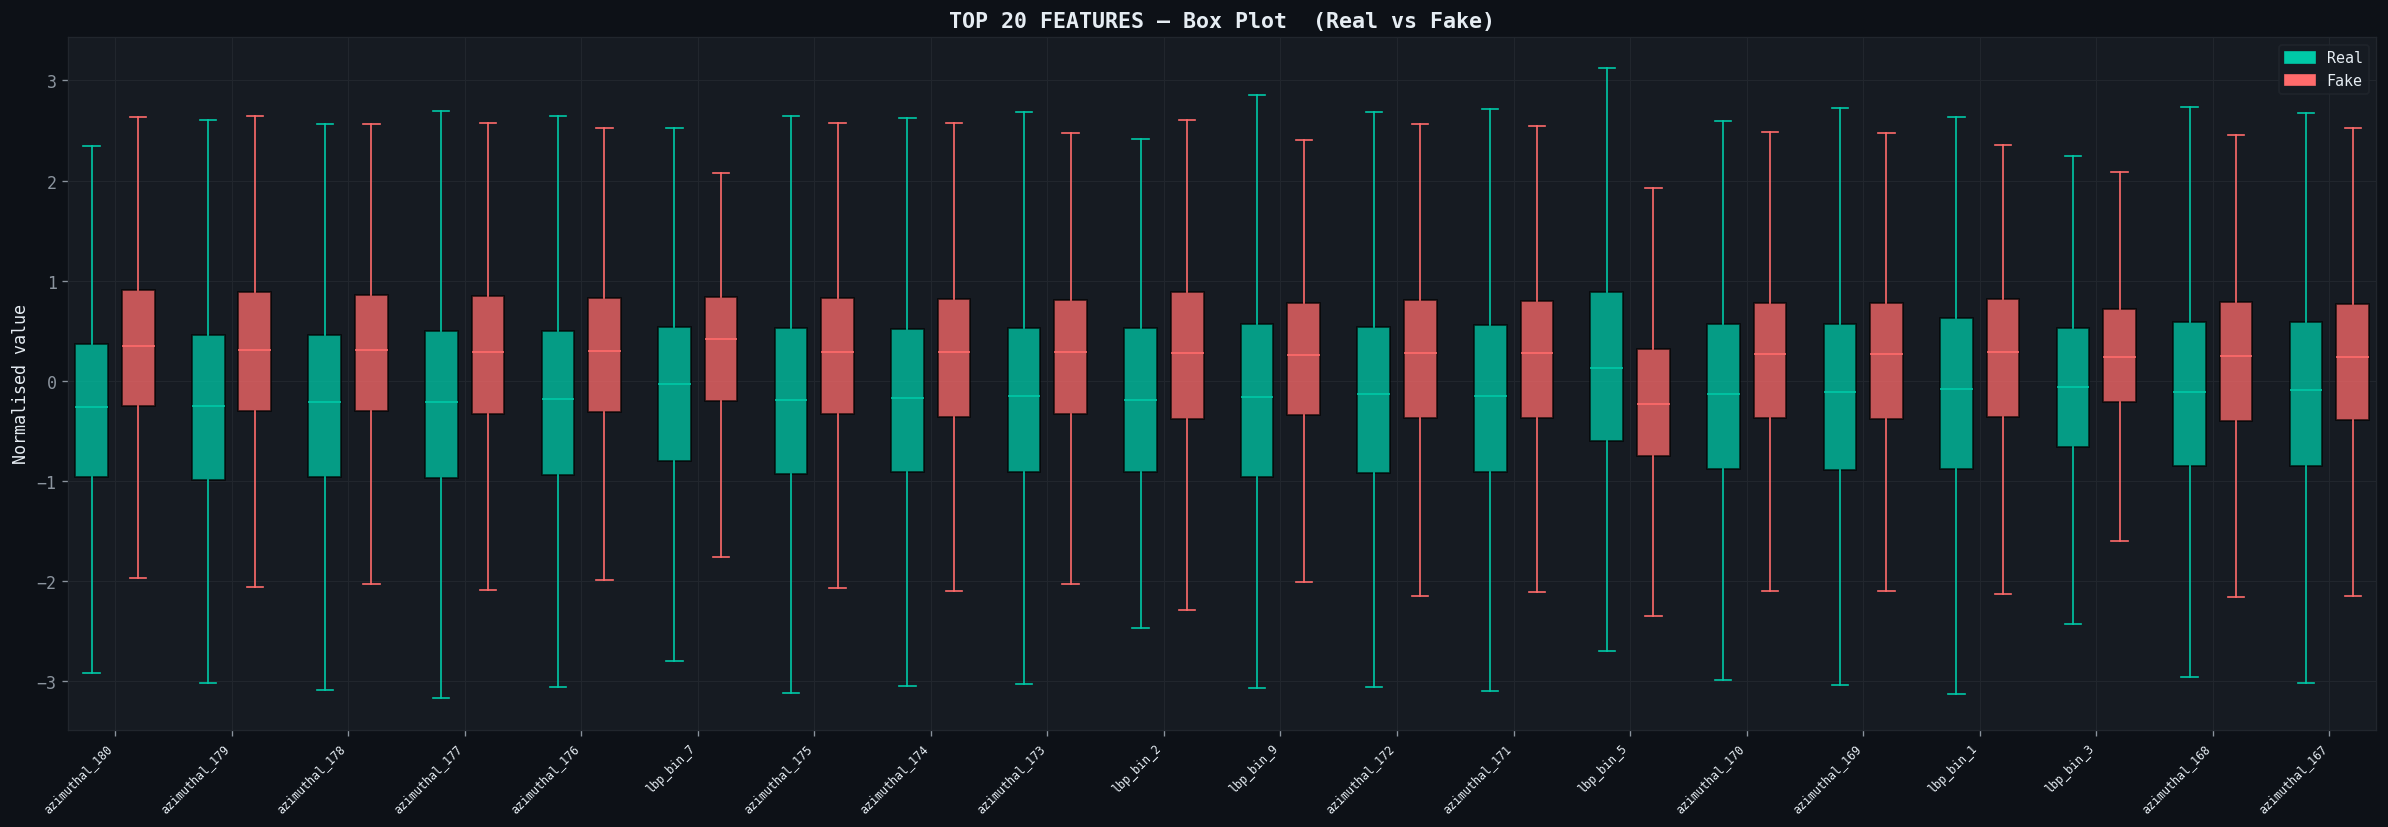

✓  MediaLab\plots\02_top_features_boxplot.png


In [17]:
def plot_boxplots(X, y, out_path):
    apply_dark_style()
    scaler = StandardScaler()
    Xs     = scaler.fit_transform(X)
    X_real = Xs[y == 0]
    X_fake = Xs[y == 1]

    pvals = [ttest_ind(X_real[:, i], X_fake[:, i], equal_var=False)[1]
             for i in range(X.shape[1])]
    top20 = np.argsort(pvals)[:20]
    names = [FEATURE_NAMES[i] if i < len(FEATURE_NAMES) else f"f{i}" for i in top20]

    fig, ax = plt.subplots(figsize=(20, 7))
    fig.patch.set_facecolor(BG_COLOR)

    positions_real = np.arange(len(top20)) * 2.5
    positions_fake = positions_real + 1.0

    bp_real = ax.boxplot([X_real[:, i] for i in top20], positions=positions_real,
                          widths=0.7, patch_artist=True, showfliers=False)
    bp_fake = ax.boxplot([X_fake[:, i] for i in top20], positions=positions_fake,
                          widths=0.7, patch_artist=True, showfliers=False)

    for patch in bp_real["boxes"]:
        patch.set_facecolor(REAL_COLOR); patch.set_alpha(0.75)
    for patch in bp_fake["boxes"]:
        patch.set_facecolor(FAKE_COLOR); patch.set_alpha(0.75)
    for element in ["whiskers", "caps", "medians"]:
        for line in bp_real[element]: line.set_color(REAL_COLOR)
        for line in bp_fake[element]: line.set_color(FAKE_COLOR)

    ax.set_xticks(positions_real + 0.5)
    ax.set_xticklabels(names, rotation=45, ha="right", fontsize=7, color=TEXT_COLOR)
    ax.set_ylabel("Normalised value", color=TEXT_COLOR)
    ax.set_title("TOP 20 FEATURES — Box Plot  (Real vs Fake)",
                 fontsize=13, color=TEXT_COLOR, fontweight="bold")
    ax.legend(handles=[Patch(color=REAL_COLOR, label="Real"),
                        Patch(color=FAKE_COLOR, label="Fake")],
              loc="upper right", fontsize=9)

    plt.tight_layout()
    plt.savefig(out_path, bbox_inches="tight", facecolor=BG_COLOR)
    plt.show()
    plt.close()
    print(f"✓  {out_path}")


plot_boxplots(X, y, OUT_DIR / "plots" / "02_top_features_boxplot.png")


---
## Part 8 — Plot 03: Correlation Heatmap

Pearson correlation matrix for the **top 40 features** with group boundary lines.

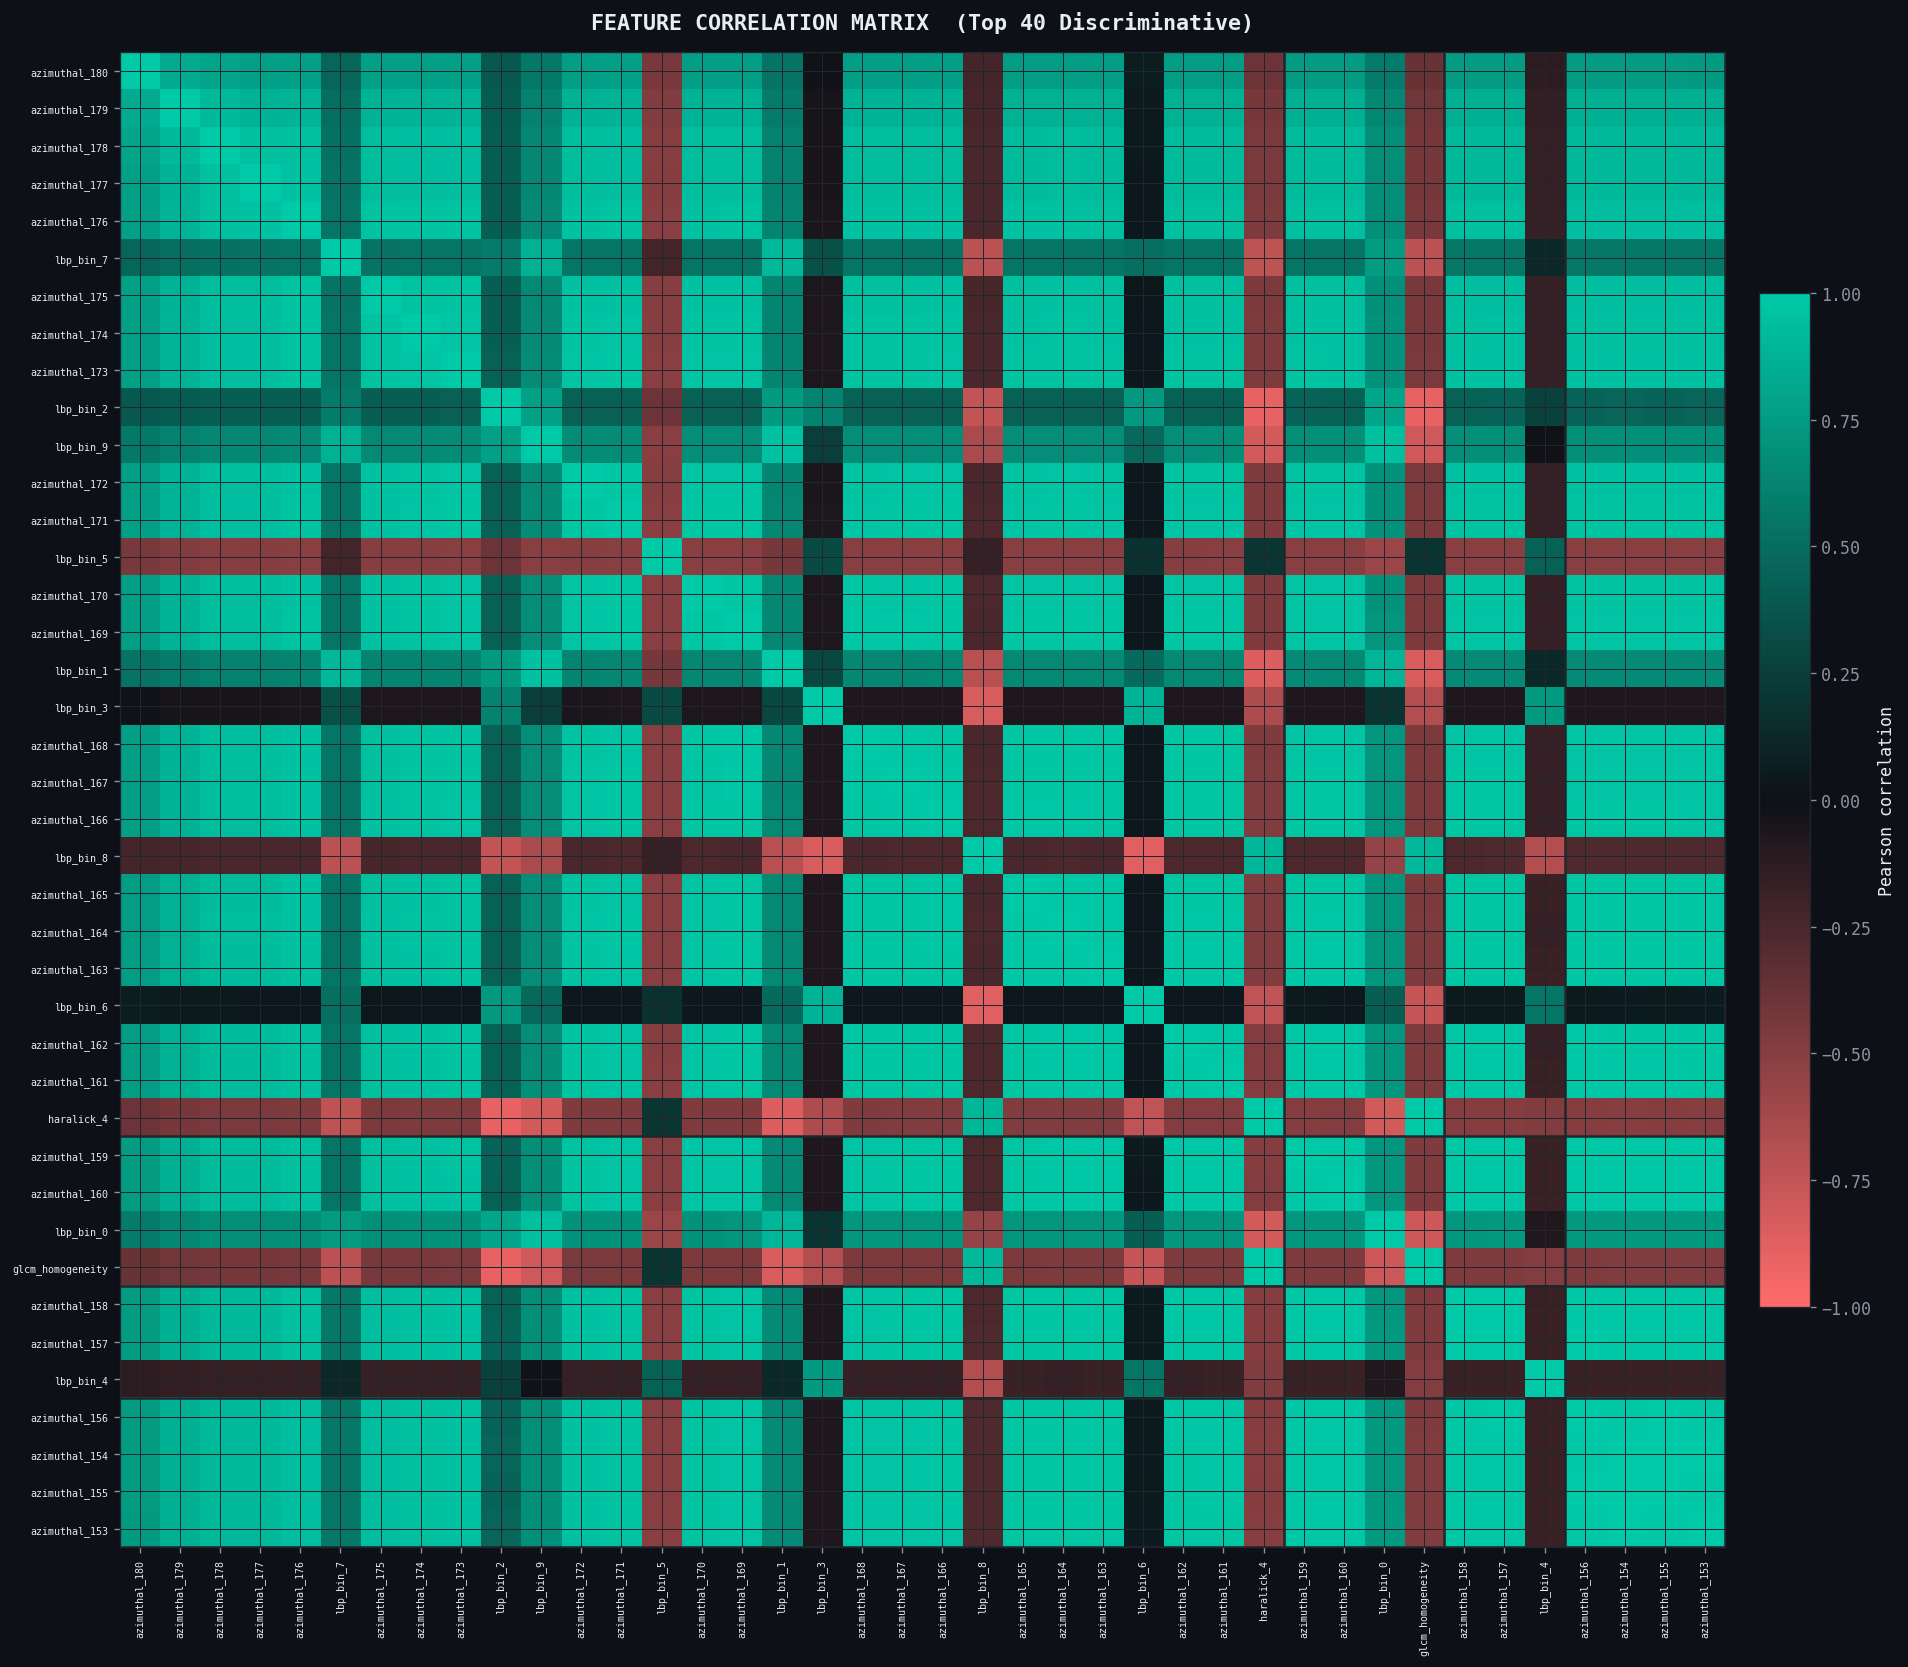

✓  MediaLab\plots\03_correlation_heatmap.png


In [18]:
def plot_correlation_heatmap(X, y, out_path):
    apply_dark_style()
    scaler = StandardScaler()
    Xs     = scaler.fit_transform(X)
    X_real = Xs[y == 0]
    X_fake = Xs[y == 1]

    pvals = [ttest_ind(X_real[:, i], X_fake[:, i], equal_var=False)[1]
             for i in range(X.shape[1])]
    top40 = np.argsort(pvals)[:40]
    names = [FEATURE_NAMES[i] if i < len(FEATURE_NAMES) else f"f{i}" for i in top40]

    corr = np.corrcoef(Xs[:, top40].T)

    fig, ax = plt.subplots(figsize=(16, 14))
    fig.patch.set_facecolor(BG_COLOR)

    im = ax.imshow(corr, cmap=DIV_CMAP, vmin=-1, vmax=1, aspect="auto")
    plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02,
                 label="Pearson correlation").ax.yaxis.set_tick_params(color=MUTED)

    ax.set_xticks(range(40)); ax.set_yticks(range(40))
    ax.set_xticklabels(names, rotation=90, fontsize=6, color=TEXT_COLOR)
    ax.set_yticklabels(names, fontsize=6, color=TEXT_COLOR)
    ax.set_title("FEATURE CORRELATION MATRIX  (Top 40 Discriminative)",
                 fontsize=13, color=TEXT_COLOR, fontweight="bold", pad=14)

    # Group divider lines
    for gname, (gs, ge) in FEATURE_GROUPS.items():
        idxs_in_top = [j for j, fi in enumerate(top40) if gs <= fi < ge]
        if idxs_in_top:
            boundary = max(idxs_in_top) + 0.5
            ax.axhline(boundary, color=GRID_COLOR, linewidth=1.5)
            ax.axvline(boundary, color=GRID_COLOR, linewidth=1.5)

    plt.tight_layout()
    plt.savefig(out_path, bbox_inches="tight", facecolor=BG_COLOR, dpi=130)
    plt.show()
    plt.close()
    print(f"✓  {out_path}")


plot_correlation_heatmap(X, y, OUT_DIR / "plots" / "03_correlation_heatmap.png")


---
## Part 9 — Plot 04: Feature Group Means

Grouped bar chart showing **mean absolute activation per descriptor family** for Real vs Fake.

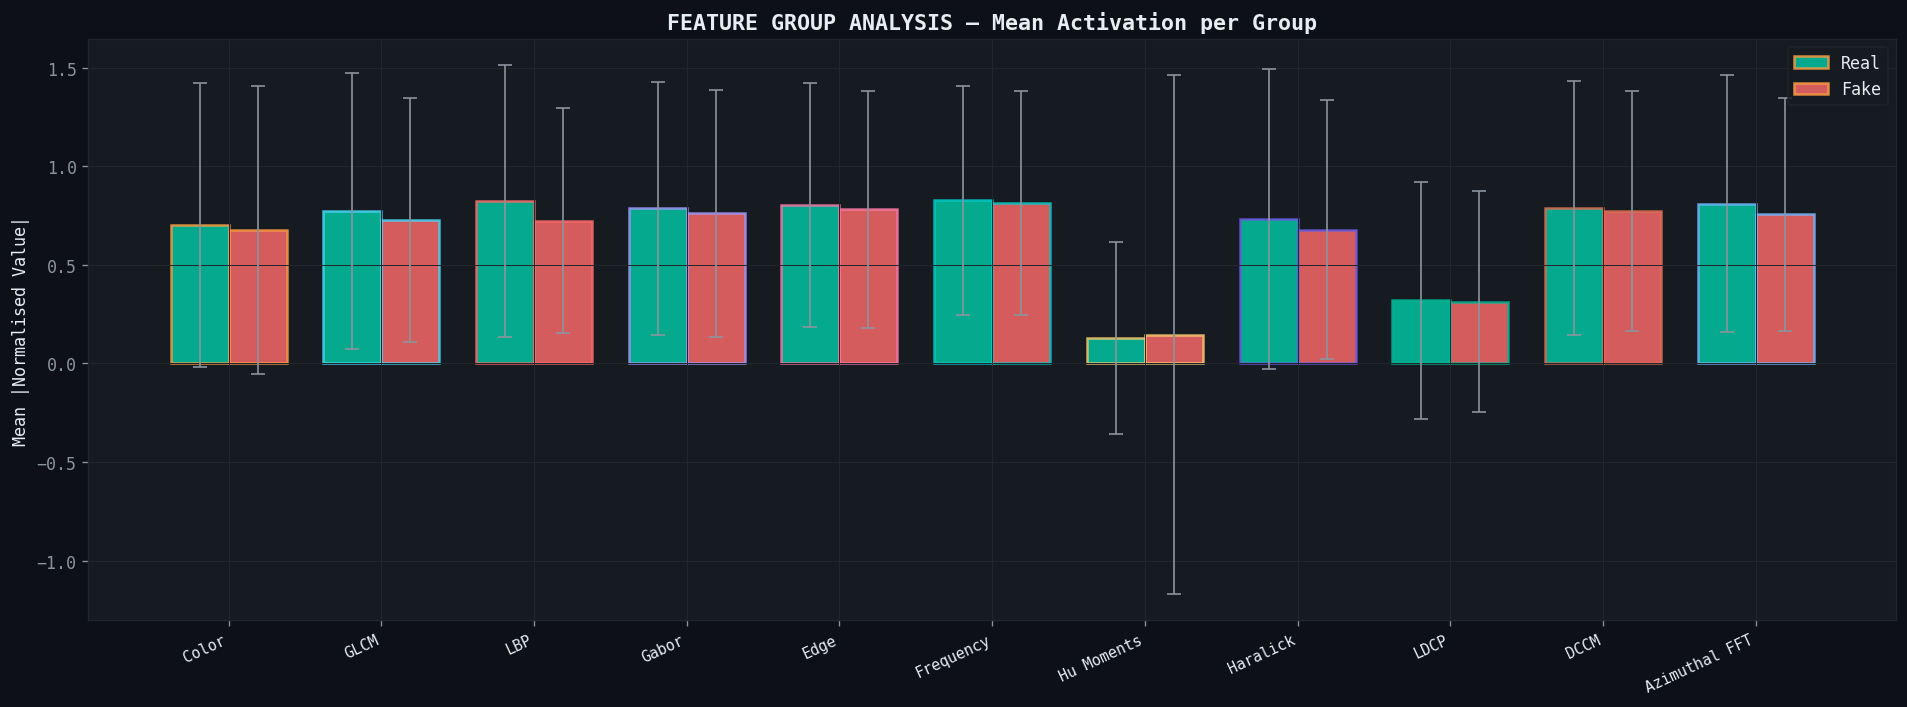

✓  MediaLab\plots\04_feature_group_means.png


In [19]:
def plot_feature_group_means(X, y, out_path):
    apply_dark_style()
    scaler = StandardScaler()
    Xs     = scaler.fit_transform(X)
    X_real = Xs[y == 0]
    X_fake = Xs[y == 1]

    groups     = list(FEATURE_GROUPS.keys())
    real_means, fake_means = [], []
    real_stds,  fake_stds  = [], []

    for g in groups:
        s, e = FEATURE_GROUPS[g]
        e    = min(e, X.shape[1])
        real_means.append(np.mean(np.abs(X_real[:, s:e])))
        fake_means.append(np.mean(np.abs(X_fake[:, s:e])))
        real_stds.append(np.std(np.abs(X_real[:, s:e])))
        fake_stds.append(np.std(np.abs(X_fake[:, s:e])))

    x     = np.arange(len(groups))
    width = 0.38

    fig, ax = plt.subplots(figsize=(16, 6))
    fig.patch.set_facecolor(BG_COLOR)

    bars_r = ax.bar(x - width/2, real_means, width, yerr=real_stds,
                    color=REAL_COLOR, alpha=0.82, label="Real",
                    error_kw=dict(ecolor=MUTED, capsize=4, linewidth=1))
    bars_f = ax.bar(x + width/2, fake_means, width, yerr=fake_stds,
                    color=FAKE_COLOR, alpha=0.82, label="Fake",
                    error_kw=dict(ecolor=MUTED, capsize=4, linewidth=1))

    # Colour bar edges by group
    for bar, g in zip(bars_r, groups):
        bar.set_edgecolor(GROUP_COLORS[g]); bar.set_linewidth(1.5)
    for bar, g in zip(bars_f, groups):
        bar.set_edgecolor(GROUP_COLORS[g]); bar.set_linewidth(1.5)

    ax.set_xticks(x)
    ax.set_xticklabels(groups, rotation=25, ha="right", fontsize=9, color=TEXT_COLOR)
    ax.set_ylabel("Mean |Normalised Value|", color=TEXT_COLOR)
    ax.set_title("FEATURE GROUP ANALYSIS — Mean Activation per Group",
                 fontsize=13, color=TEXT_COLOR, fontweight="bold")
    ax.legend(fontsize=10)

    plt.tight_layout()
    plt.savefig(out_path, bbox_inches="tight", facecolor=BG_COLOR)
    plt.show()
    plt.close()
    print(f"✓  {out_path}")


plot_feature_group_means(X, y, OUT_DIR / "plots" / "04_feature_group_means.png")


---
## Part 10 — Plot 05: Azimuthal FFT Spectrum

Mean radial power spectrum for Real vs Fake with ±1σ confidence band and |Δ| overlay.

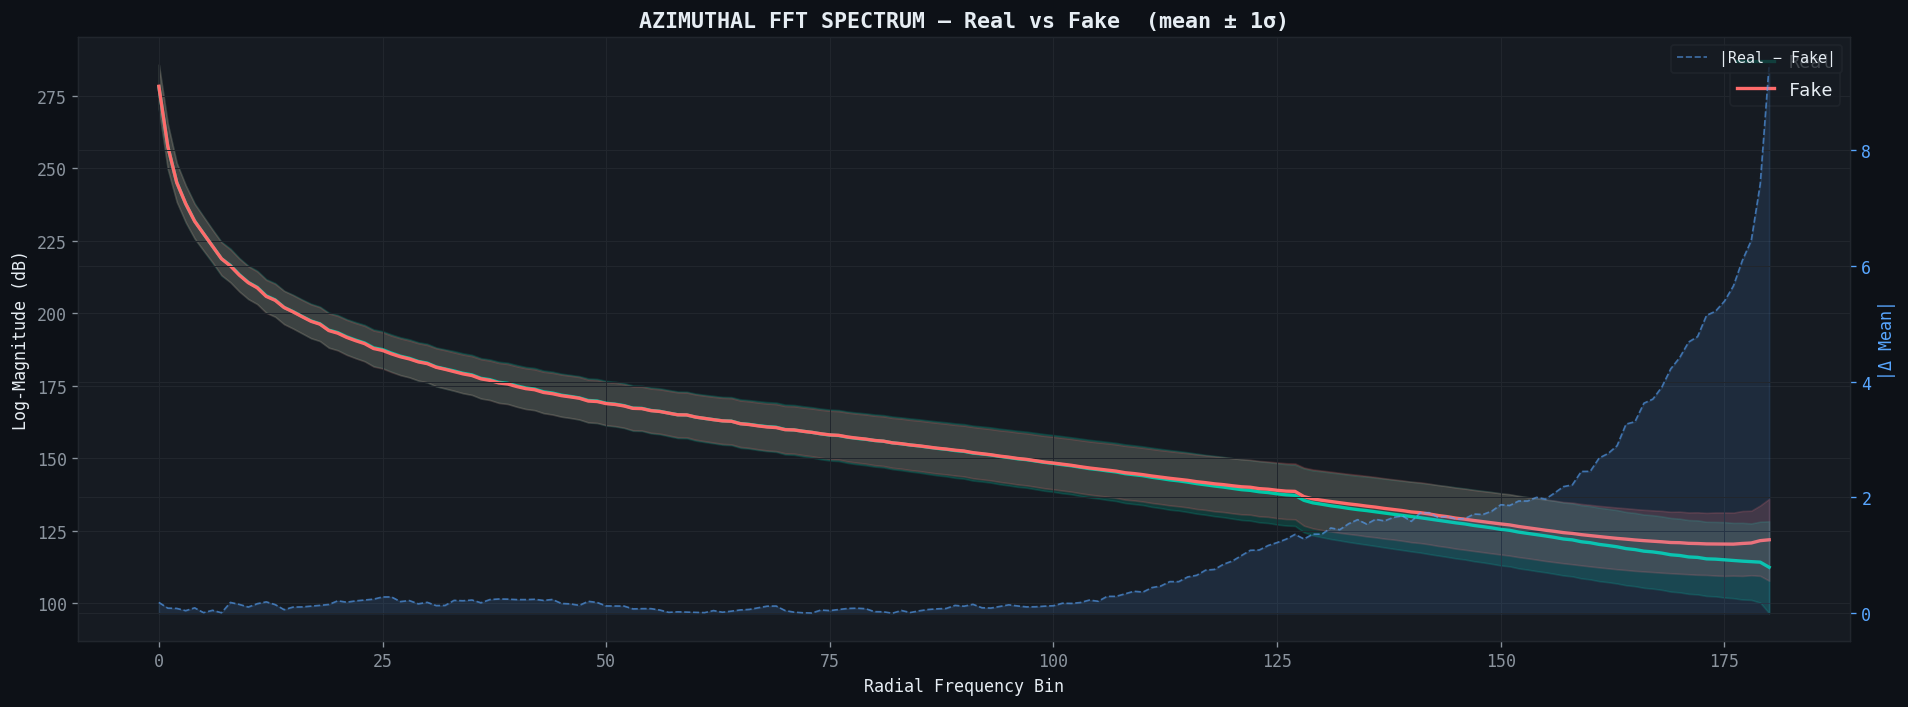

✓  MediaLab\plots\05_azimuthal_fft.png


In [21]:
def plot_azimuthal_fft(X, y, out_path):
    apply_dark_style()
    az_start, az_end = FEATURE_GROUPS["Azimuthal FFT"]
    az_end   = min(az_end, X.shape[1])

    X_real = X[y == 0, az_start:az_end]
    X_fake = X[y == 1, az_start:az_end]

    r_mean = np.mean(X_real, axis=0)
    f_mean = np.mean(X_fake, axis=0)
    r_std  = np.std(X_real,  axis=0)
    f_std  = np.std(X_fake,  axis=0)
    freqs  = np.arange(len(r_mean))

    fig, ax = plt.subplots(figsize=(16, 6))
    fig.patch.set_facecolor(BG_COLOR)

    ax.plot(freqs, r_mean, color=REAL_COLOR, linewidth=2, label="Real")
    ax.fill_between(freqs, r_mean - r_std, r_mean + r_std,
                    color=REAL_COLOR, alpha=0.18)
    ax.plot(freqs, f_mean, color=FAKE_COLOR, linewidth=2, label="Fake")
    ax.fill_between(freqs, f_mean - f_std, f_mean + f_std,
                    color=FAKE_COLOR, alpha=0.18)

    ax.set_xlabel("Radial Frequency Bin", color=TEXT_COLOR)
    ax.set_ylabel("Log-Magnitude (dB)",   color=TEXT_COLOR)
    ax.set_title("AZIMUTHAL FFT SPECTRUM — Real vs Fake  (mean ± 1σ)",
                 fontsize=13, color=TEXT_COLOR, fontweight="bold")
    ax.legend(fontsize=11)

    # |Δ| overlay on secondary y-axis
    diff = np.abs(r_mean - f_mean)
    ax2  = ax.twinx()
    ax2.fill_between(freqs, diff, alpha=0.12, color=ACCENT)
    ax2.plot(freqs, diff, color=ACCENT, linewidth=1, alpha=0.6,
             linestyle="--", label="|Real − Fake|")
    ax2.set_ylabel("|Δ Mean|", color=ACCENT)
    ax2.tick_params(colors=ACCENT)
    ax2.legend(fontsize=9, loc="upper right")
    ax2.set_facecolor(PANEL_COLOR)

    plt.tight_layout()
    plt.savefig(out_path, bbox_inches="tight", facecolor=BG_COLOR)
    plt.show()
    plt.close()
    print(f"✓  {out_path}")


plot_azimuthal_fft(X, y, OUT_DIR / "plots" / "05_azimuthal_fft.png")


---
## Part 11 — Plot 06: PCA Variance

Scree plot showing explained variance per principal component + PC1 vs PC2 class scatter.

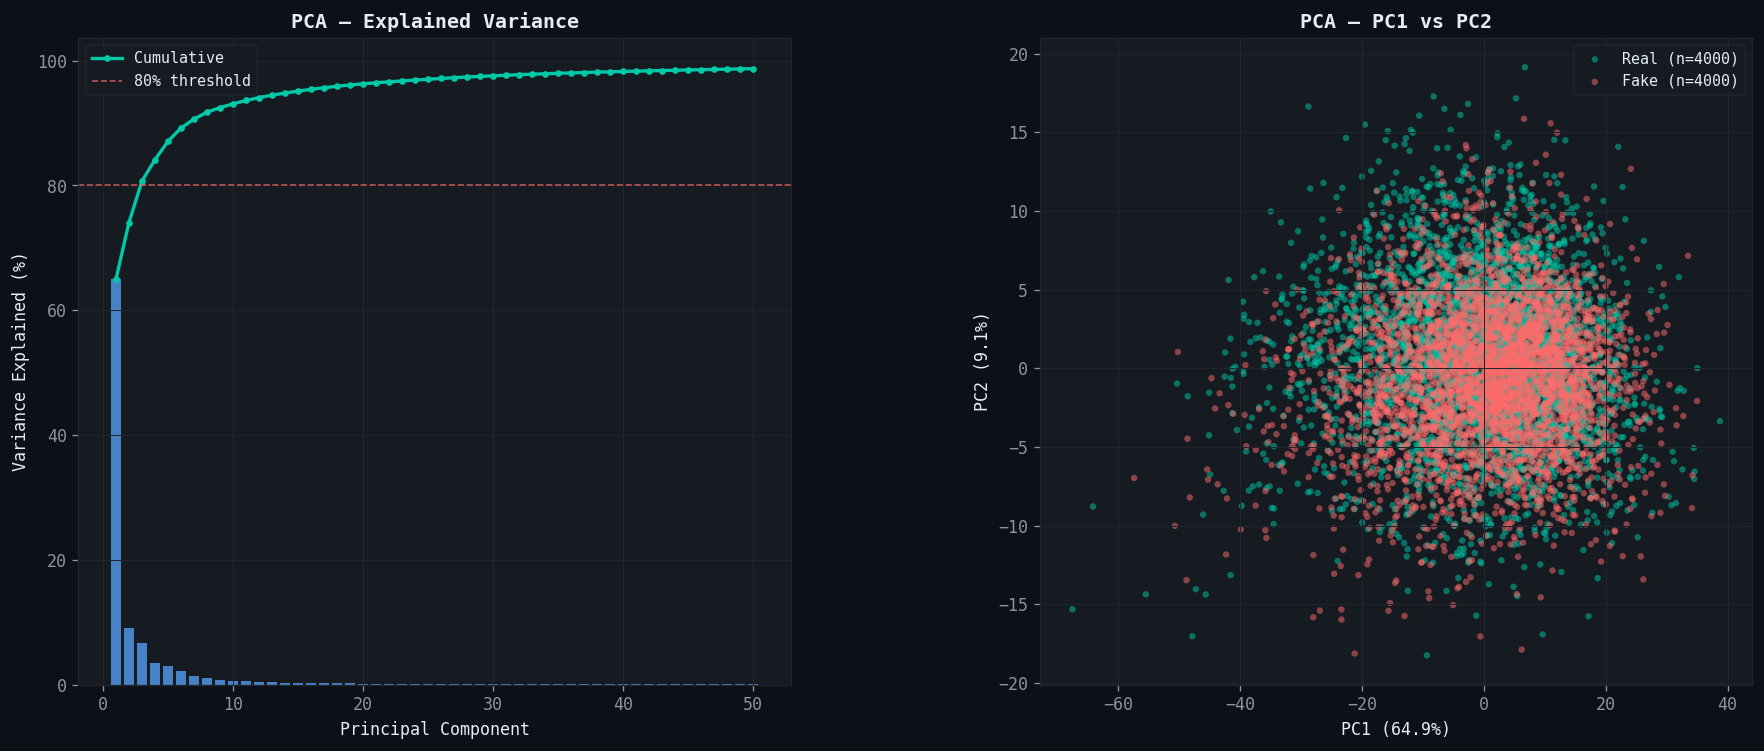

✓  MediaLab\plots\06_pca_variance.png


In [22]:
def plot_pca_variance(X, y, out_path):
    apply_dark_style()
    scaler = StandardScaler()
    Xs     = scaler.fit_transform(X)
    n_comp = min(50, Xs.shape[1], Xs.shape[0] - 1)
    pca    = PCA(n_components=n_comp, random_state=42)
    Xp     = pca.fit_transform(Xs)

    fig = plt.figure(figsize=(18, 7))
    fig.patch.set_facecolor(BG_COLOR)
    gs  = gridspec.GridSpec(1, 2, figure=fig, wspace=0.35)

    # Left: explained variance scree plot
    ax1 = fig.add_subplot(gs[0])
    ev  = pca.explained_variance_ratio_ * 100
    cum = np.cumsum(ev)
    ax1.bar(range(1, n_comp + 1), ev, color=ACCENT, alpha=0.75)
    ax1.plot(range(1, n_comp + 1), cum, color=REAL_COLOR, linewidth=2,
             marker="o", markersize=3, label="Cumulative")
    ax1.axhline(80, color=FAKE_COLOR, linewidth=1, linestyle="--",
                alpha=0.7, label="80% threshold")
    ax1.set_xlabel("Principal Component", color=TEXT_COLOR)
    ax1.set_ylabel("Variance Explained (%)", color=TEXT_COLOR)
    ax1.set_title("PCA — Explained Variance",
                  fontsize=12, color=TEXT_COLOR, fontweight="bold")
    ax1.legend(fontsize=9)

    # Right: PC1 vs PC2 scatter
    ax2 = fig.add_subplot(gs[1])
    ax2.scatter(Xp[y == 0, 0], Xp[y == 0, 1], c=REAL_COLOR, alpha=0.5, s=15,
                label=f"Real (n={np.sum(y==0)})", edgecolors="none")
    ax2.scatter(Xp[y == 1, 0], Xp[y == 1, 1], c=FAKE_COLOR, alpha=0.5, s=15,
                label=f"Fake (n={np.sum(y==1)})", edgecolors="none")
    ax2.set_xlabel(f"PC1 ({ev[0]:.1f}%)", color=TEXT_COLOR)
    ax2.set_ylabel(f"PC2 ({ev[1]:.1f}%)", color=TEXT_COLOR)
    ax2.set_title("PCA — PC1 vs PC2",
                  fontsize=12, color=TEXT_COLOR, fontweight="bold")
    ax2.legend(fontsize=9)

    plt.savefig(out_path, bbox_inches="tight", facecolor=BG_COLOR)
    plt.show()
    plt.close()
    print(f"✓  {out_path}")


plot_pca_variance(X, y, OUT_DIR / "plots" / "06_pca_variance.png")


---
## Part 12 — Plot 07: t-SNE Projection

2D non-linear embedding (PCA→50 dims first for speed) with KDE density contours per class.

> ⏳ This cell typically takes **1–2 minutes** to complete.

  Running t-SNE (may take ~1–2 min) …


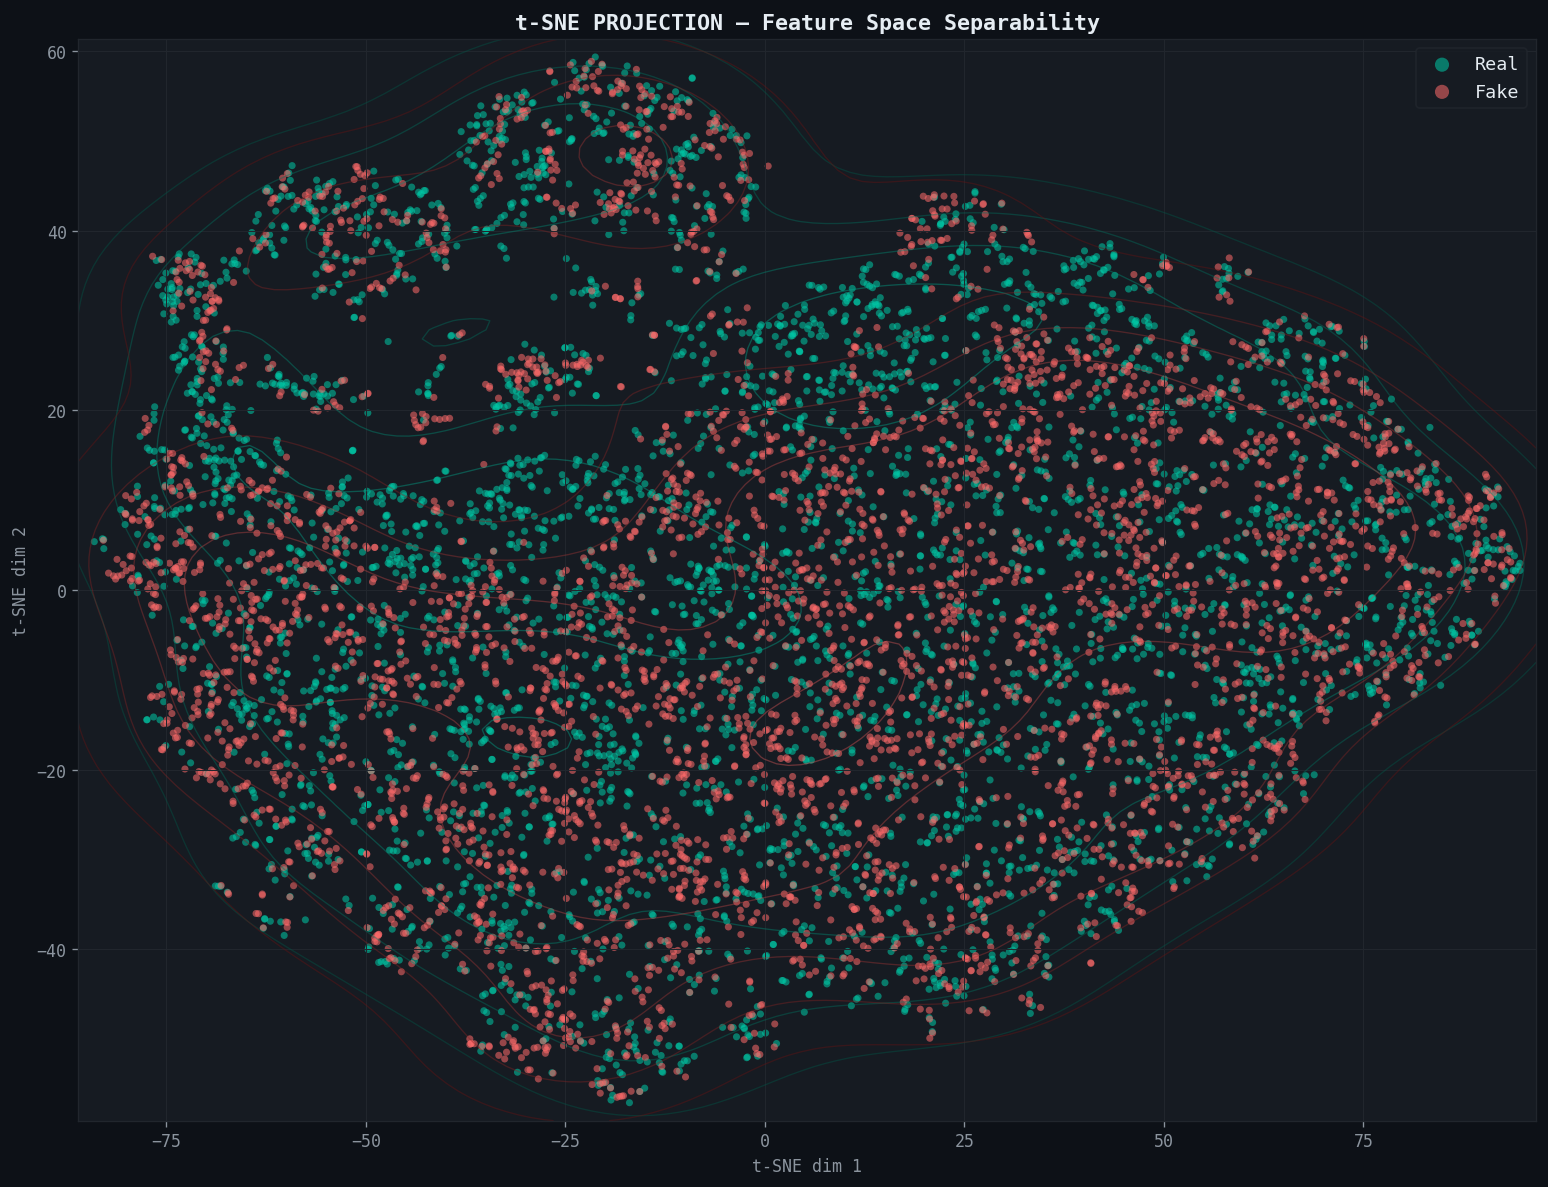

✓  MediaLab\plots\07_tsne_projection.png


In [23]:
def plot_tsne(X, y, out_path):
    apply_dark_style()
    scaler = StandardScaler()
    Xs     = scaler.fit_transform(X)

    # Reduce to 50 dims first for speed
    pca50 = PCA(n_components=min(50, Xs.shape[1]), random_state=42)
    Xpca  = pca50.fit_transform(Xs)

    print("  Running t-SNE (may take ~1–2 min) …")
    tsne = TSNE(n_components=2, perplexity=min(30, len(y) - 1),
                random_state=42, max_iter=1000)
    Xt   = tsne.fit_transform(Xpca)

    fig, ax = plt.subplots(figsize=(13, 10))
    fig.patch.set_facecolor(BG_COLOR)

    ax.scatter(Xt[y == 0, 0], Xt[y == 0, 1],
               c=REAL_COLOR, alpha=0.55, s=18, label="Real", edgecolors="none")
    ax.scatter(Xt[y == 1, 0], Xt[y == 1, 1],
               c=FAKE_COLOR, alpha=0.55, s=18, label="Fake", edgecolors="none")

    # KDE density contours
    for data, cmap in [(Xt[y == 0], REAL_CMAP), (Xt[y == 1], FAKE_CMAP)]:
        try:
            kde = gaussian_kde(data.T, bw_method=0.25)
            xl  = np.linspace(Xt[:, 0].min() - 2, Xt[:, 0].max() + 2, 120)
            yl  = np.linspace(Xt[:, 1].min() - 2, Xt[:, 1].max() + 2, 120)
            XX, YY = np.meshgrid(xl, yl)
            Z   = kde(np.vstack([XX.ravel(), YY.ravel()])).reshape(XX.shape)
            ax.contour(XX, YY, Z, levels=5, cmap=cmap, alpha=0.4, linewidths=0.8)
        except Exception:
            pass

    ax.set_title("t-SNE PROJECTION — Feature Space Separability",
                 fontsize=13, color=TEXT_COLOR, fontweight="bold")
    ax.set_xlabel("t-SNE dim 1", color=MUTED)
    ax.set_ylabel("t-SNE dim 2", color=MUTED)
    ax.legend(fontsize=11, markerscale=2)

    plt.tight_layout()
    plt.savefig(out_path, bbox_inches="tight", facecolor=BG_COLOR)
    plt.show()
    plt.close()
    print(f"✓  {out_path}")


plot_tsne(X, y, OUT_DIR / "plots" / "07_tsne_projection.png")


---
## Part 13 — Plot 08: Random Forest Feature Importance

Top 30 features ranked by **Gini impurity importance**, coloured by descriptor group.

> ⏳ Trains a 100-tree Random Forest — takes ~30–60 seconds.

  Training RF for feature importance …


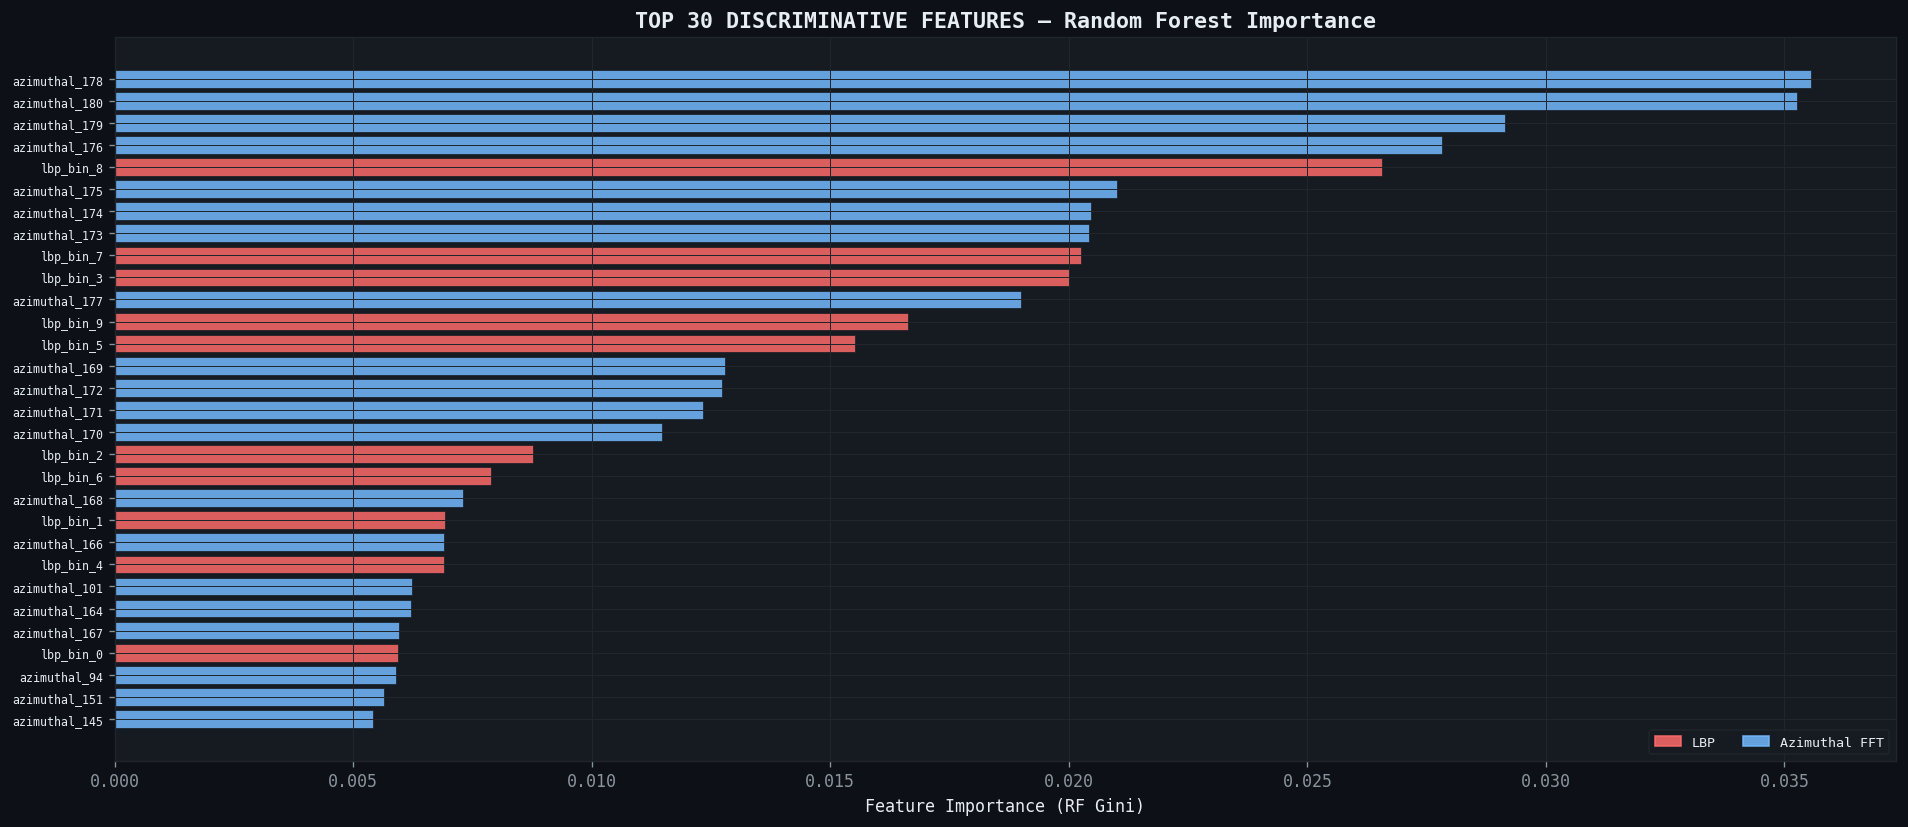

✓  MediaLab\plots\08_feature_importance.png


In [24]:
def plot_feature_importance(X, y, out_path):
    apply_dark_style()
    print("  Training RF for feature importance …")
    scaler = StandardScaler()
    Xs     = scaler.fit_transform(X)
    rf     = RandomForestClassifier(n_estimators=100, max_depth=10,
                                    n_jobs=-1, random_state=42)
    rf.fit(Xs, y)
    imp = rf.feature_importances_

    top30_idx   = np.argsort(imp)[::-1][:30]
    top30_imp   = imp[top30_idx]
    top30_names = [FEATURE_NAMES[i] if i < len(FEATURE_NAMES) else f"f{i}"
                   for i in top30_idx]

    def get_group_color(fi):
        for g, (s, e) in FEATURE_GROUPS.items():
            if s <= fi < e:
                return GROUP_COLORS[g], g
        return ACCENT, "Other"

    colors_bar  = [get_group_color(i)[0] for i in top30_idx]
    group_labels = [get_group_color(i)[1] for i in top30_idx]

    fig, ax = plt.subplots(figsize=(16, 7))
    fig.patch.set_facecolor(BG_COLOR)

    ax.barh(range(30), top30_imp, color=colors_bar,
            alpha=0.85, edgecolor=PANEL_COLOR, linewidth=0.5)
    ax.set_yticks(range(30))
    ax.set_yticklabels(top30_names, fontsize=7, color=TEXT_COLOR)
    ax.invert_yaxis()
    ax.set_xlabel("Feature Importance (RF Gini)", color=TEXT_COLOR)
    ax.set_title("TOP 30 DISCRIMINATIVE FEATURES — Random Forest Importance",
                 fontsize=13, color=TEXT_COLOR, fontweight="bold")

    # Group legend
    seen = {g: Patch(color=c, label=g, alpha=0.85)
            for g, c in GROUP_COLORS.items() if g in group_labels}
    ax.legend(handles=list(seen.values()), fontsize=8,
              loc="lower right", ncol=2)

    plt.tight_layout()
    plt.savefig(out_path, bbox_inches="tight", facecolor=BG_COLOR)
    plt.show()
    plt.close()
    print(f"✓  {out_path}")


plot_feature_importance(X, y, OUT_DIR / "plots" / "08_feature_importance.png")


---
## Part 14 — Plot 09: Radar Chart

Group-level mean absolute activation overlaid for Real vs Fake.

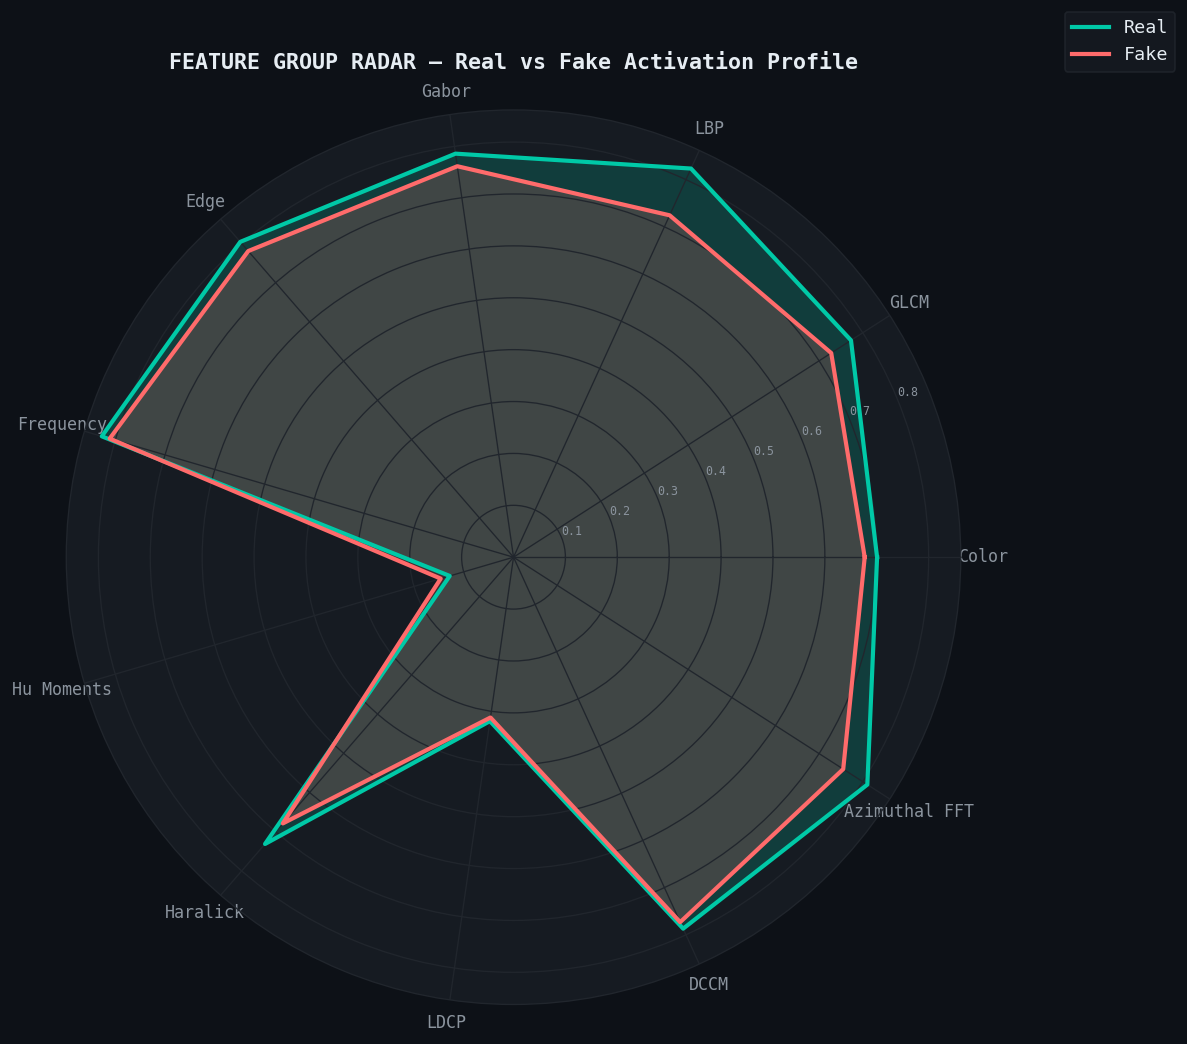

✓  MediaLab\plots\09_radar.png


In [25]:
def plot_radar(X, y, out_path):
    apply_dark_style()
    scaler = StandardScaler()
    Xs     = scaler.fit_transform(X)
    X_real = Xs[y == 0]
    X_fake = Xs[y == 1]

    groups     = list(FEATURE_GROUPS.keys())
    real_means, fake_means = [], []
    for g in groups:
        s, e = FEATURE_GROUPS[g]
        e    = min(e, Xs.shape[1])
        real_means.append(float(np.mean(np.abs(X_real[:, s:e]))))
        fake_means.append(float(np.mean(np.abs(X_fake[:, s:e]))))

    N      = len(groups)
    angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
    # Close the polygon
    angles     += angles[:1]
    real_means += real_means[:1]
    fake_means += fake_means[:1]

    fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))
    fig.patch.set_facecolor(BG_COLOR)
    ax.set_facecolor(PANEL_COLOR)

    ax.plot(angles, real_means, color=REAL_COLOR, linewidth=2.5, label="Real")
    ax.fill(angles, real_means, color=REAL_COLOR, alpha=0.2)
    ax.plot(angles, fake_means, color=FAKE_COLOR, linewidth=2.5, label="Fake")
    ax.fill(angles, fake_means, color=FAKE_COLOR, alpha=0.2)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(groups, size=10, color=TEXT_COLOR)
    ax.tick_params(colors=MUTED)
    ax.yaxis.set_tick_params(labelsize=7, labelcolor=MUTED)
    ax.spines["polar"].set_color(GRID_COLOR)
    ax.grid(color=GRID_COLOR, linewidth=0.8)

    ax.set_title("FEATURE GROUP RADAR — Real vs Fake Activation Profile",
                 fontsize=13, color=TEXT_COLOR, fontweight="bold", pad=25)
    ax.legend(loc="upper right", bbox_to_anchor=(1.25, 1.12), fontsize=11)

    plt.tight_layout()
    plt.savefig(out_path, bbox_inches="tight", facecolor=BG_COLOR)
    plt.show()
    plt.close()
    print(f"✓  {out_path}")


plot_radar(X, y, OUT_DIR / "plots" / "09_radar.png")


---
## Part 15 — Run All Plots at Once

Convenience cell to regenerate every plot in sequence.

Generating all plots → MediaLab



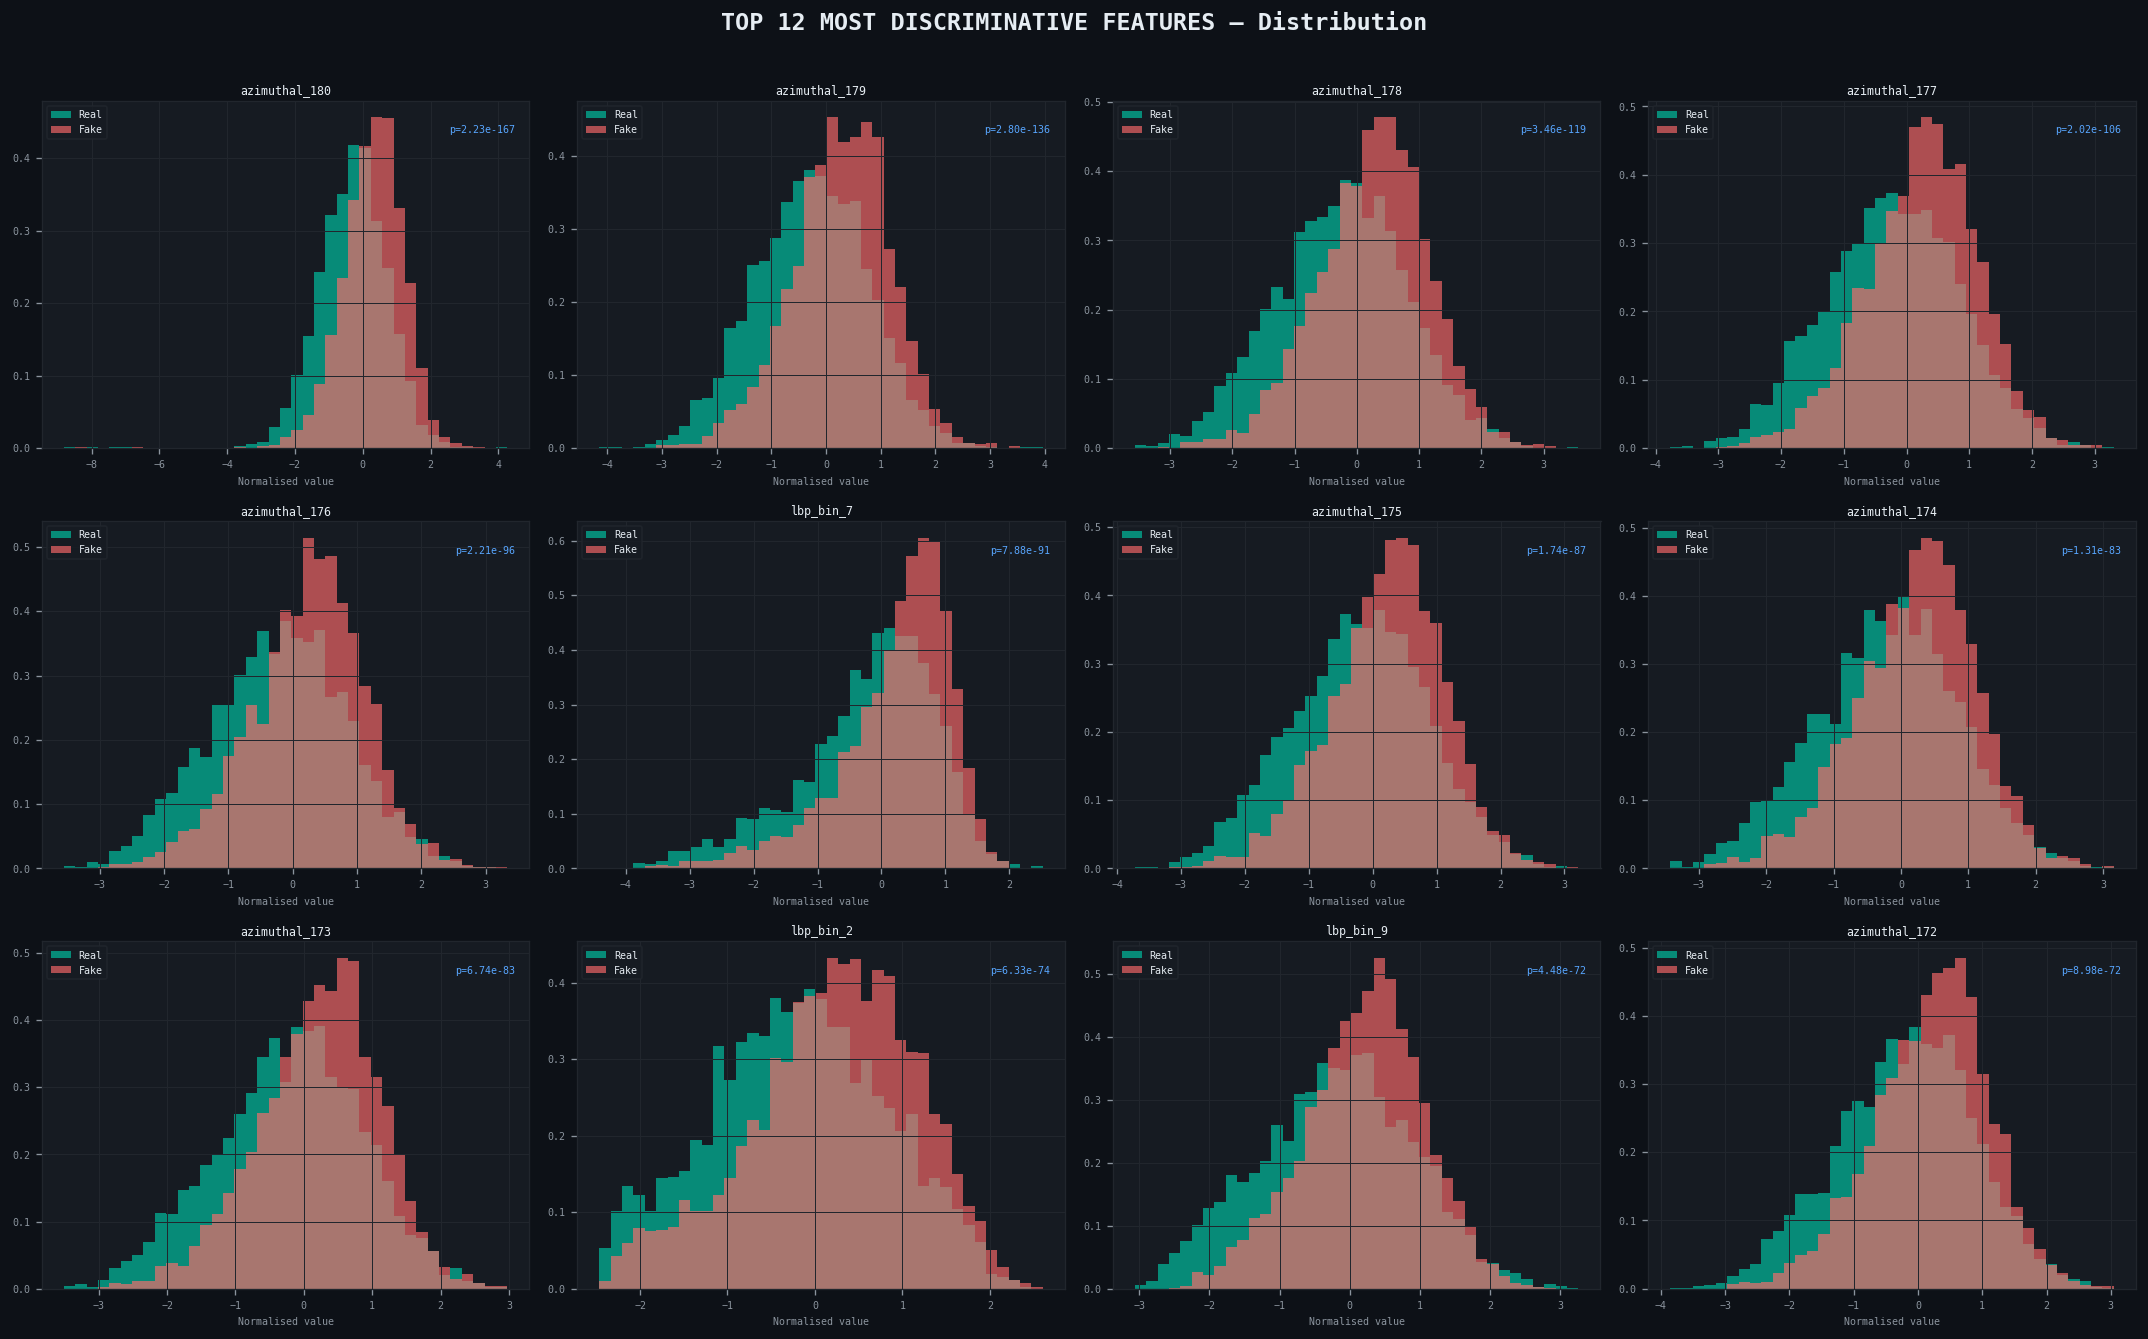

✓  MediaLab\plots\01_class_distributions.png


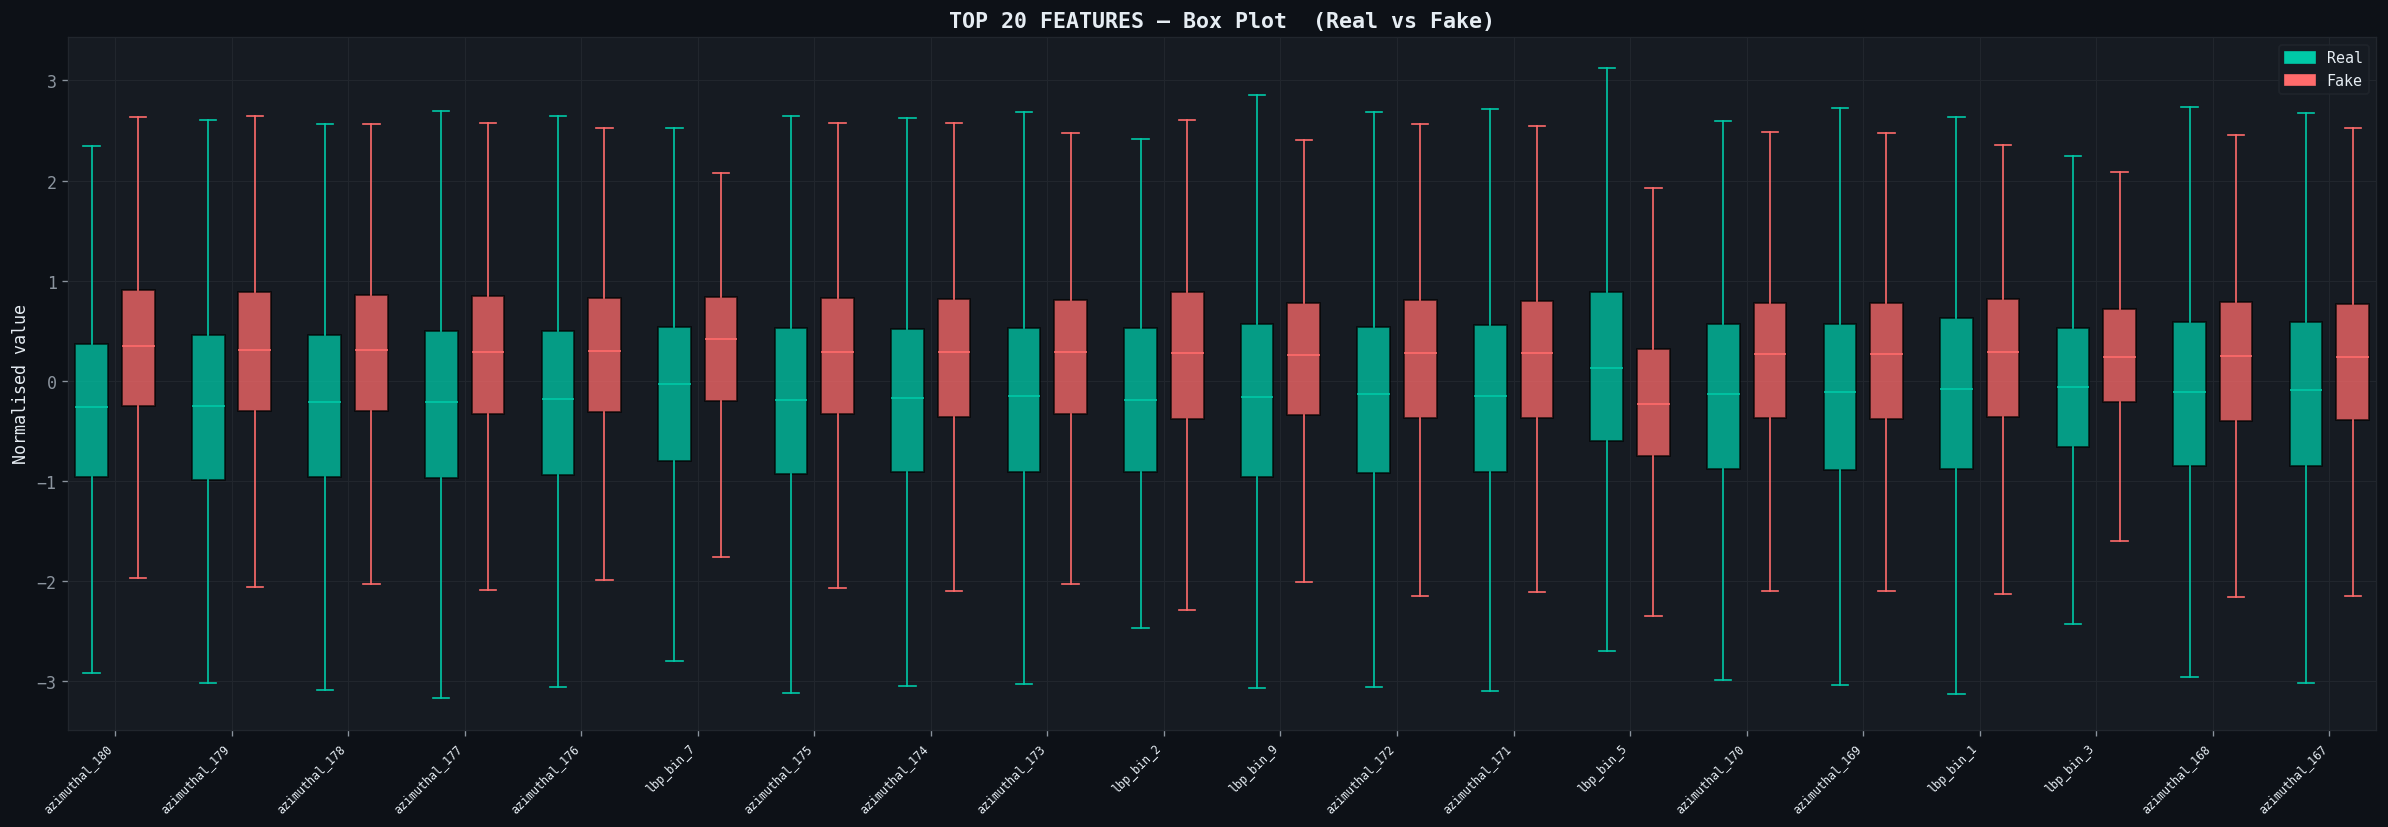

✓  MediaLab\plots\02_top_features_boxplot.png


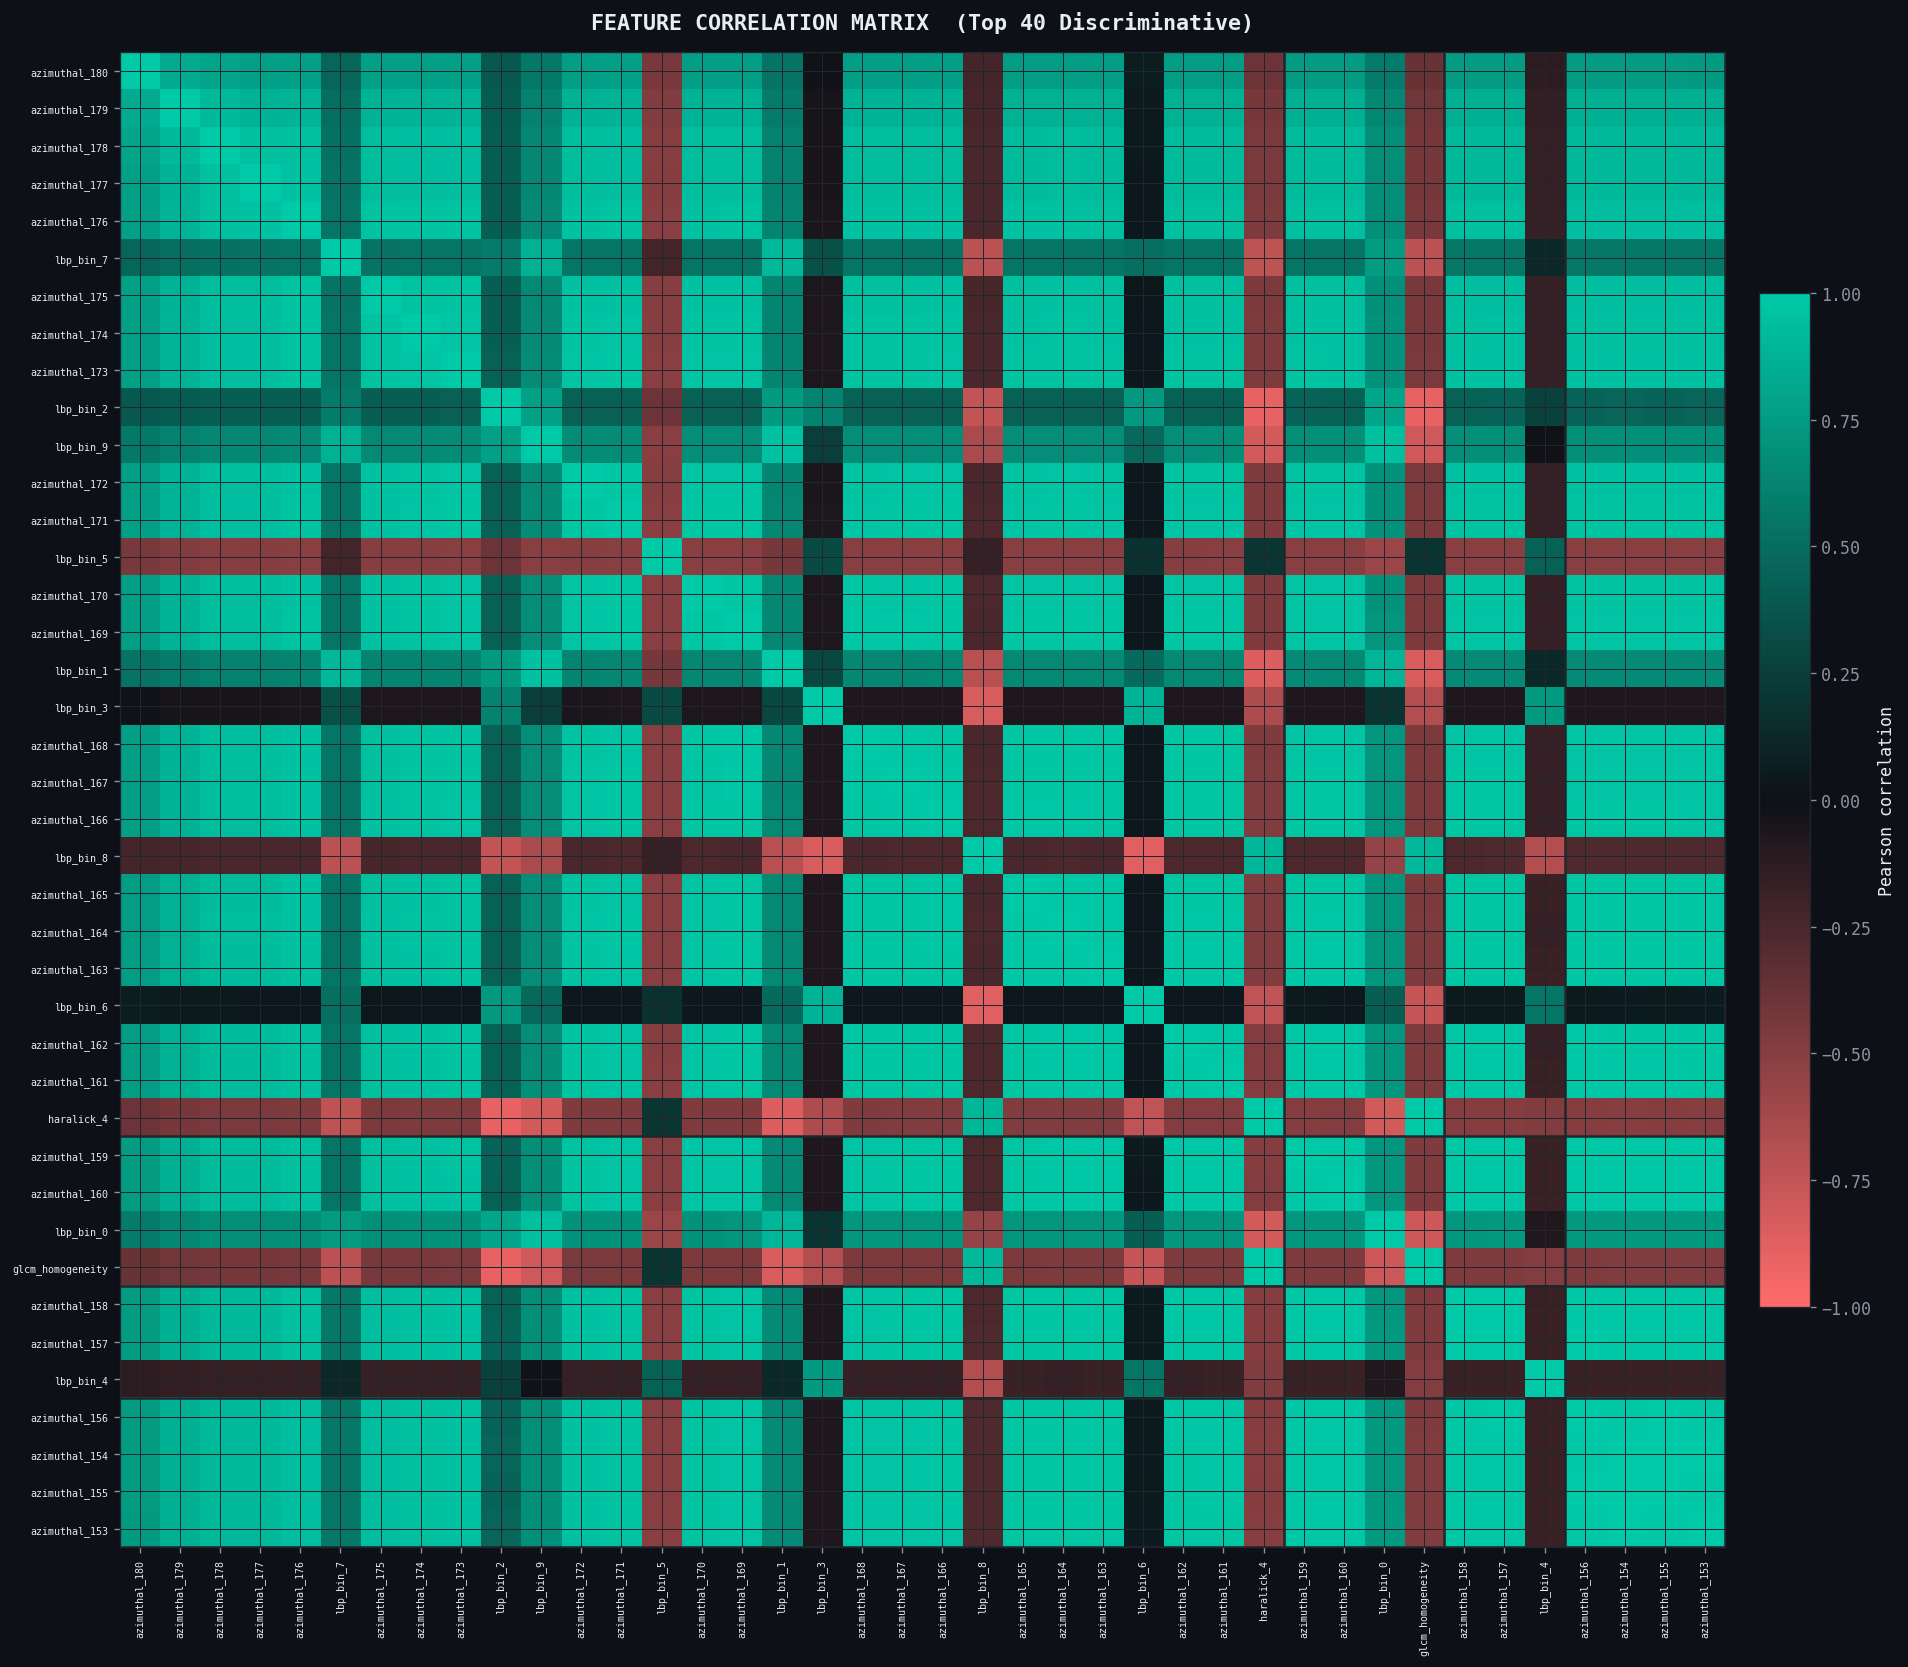

✓  MediaLab\plots\03_correlation_heatmap.png


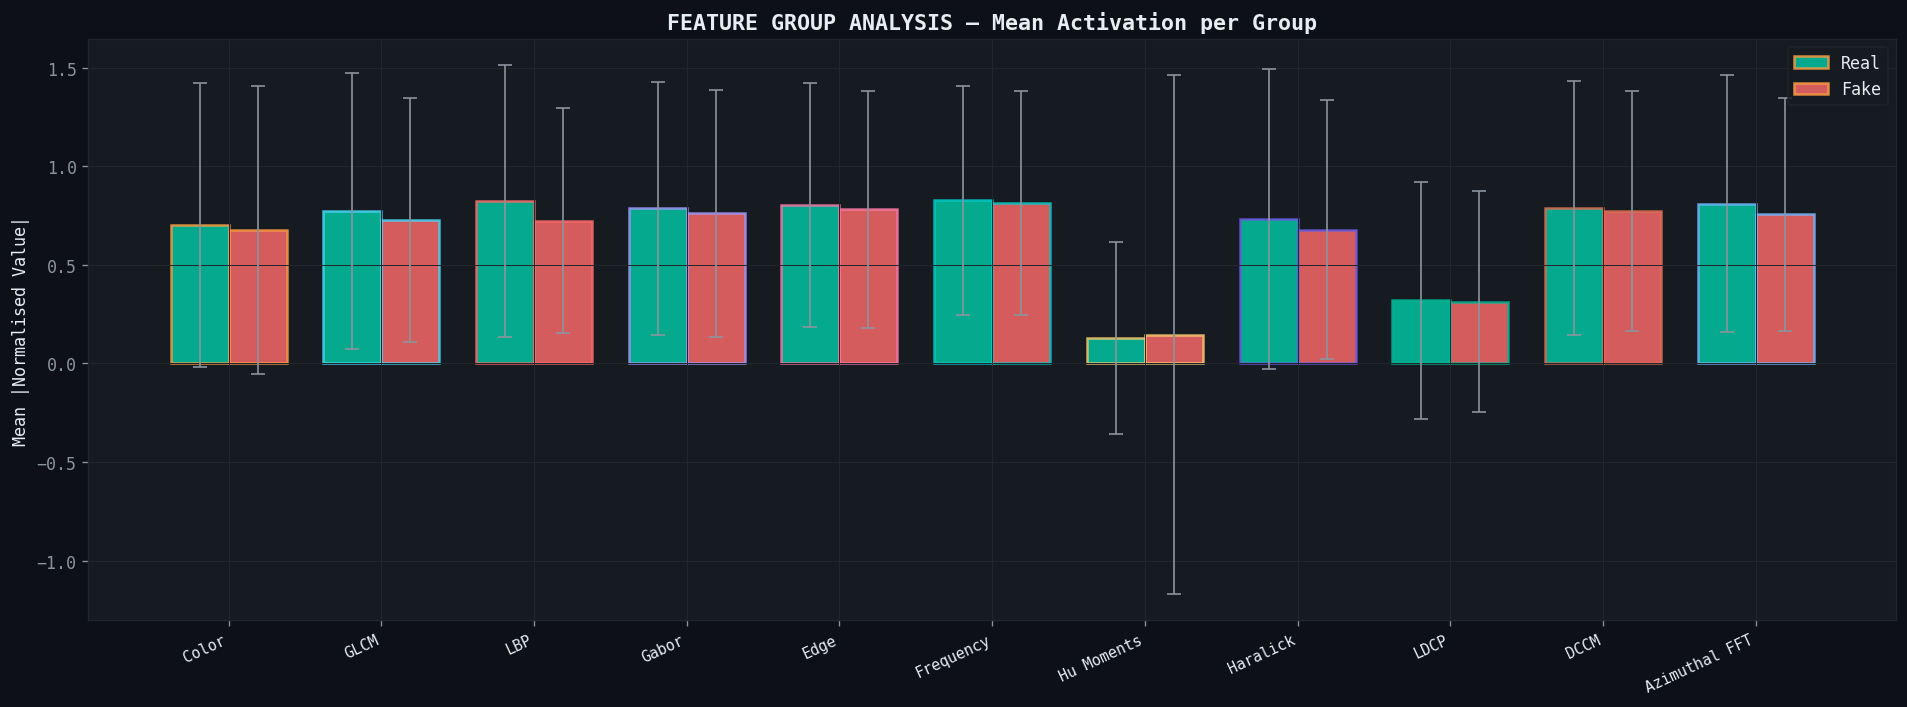

✓  MediaLab\plots\04_feature_group_means.png


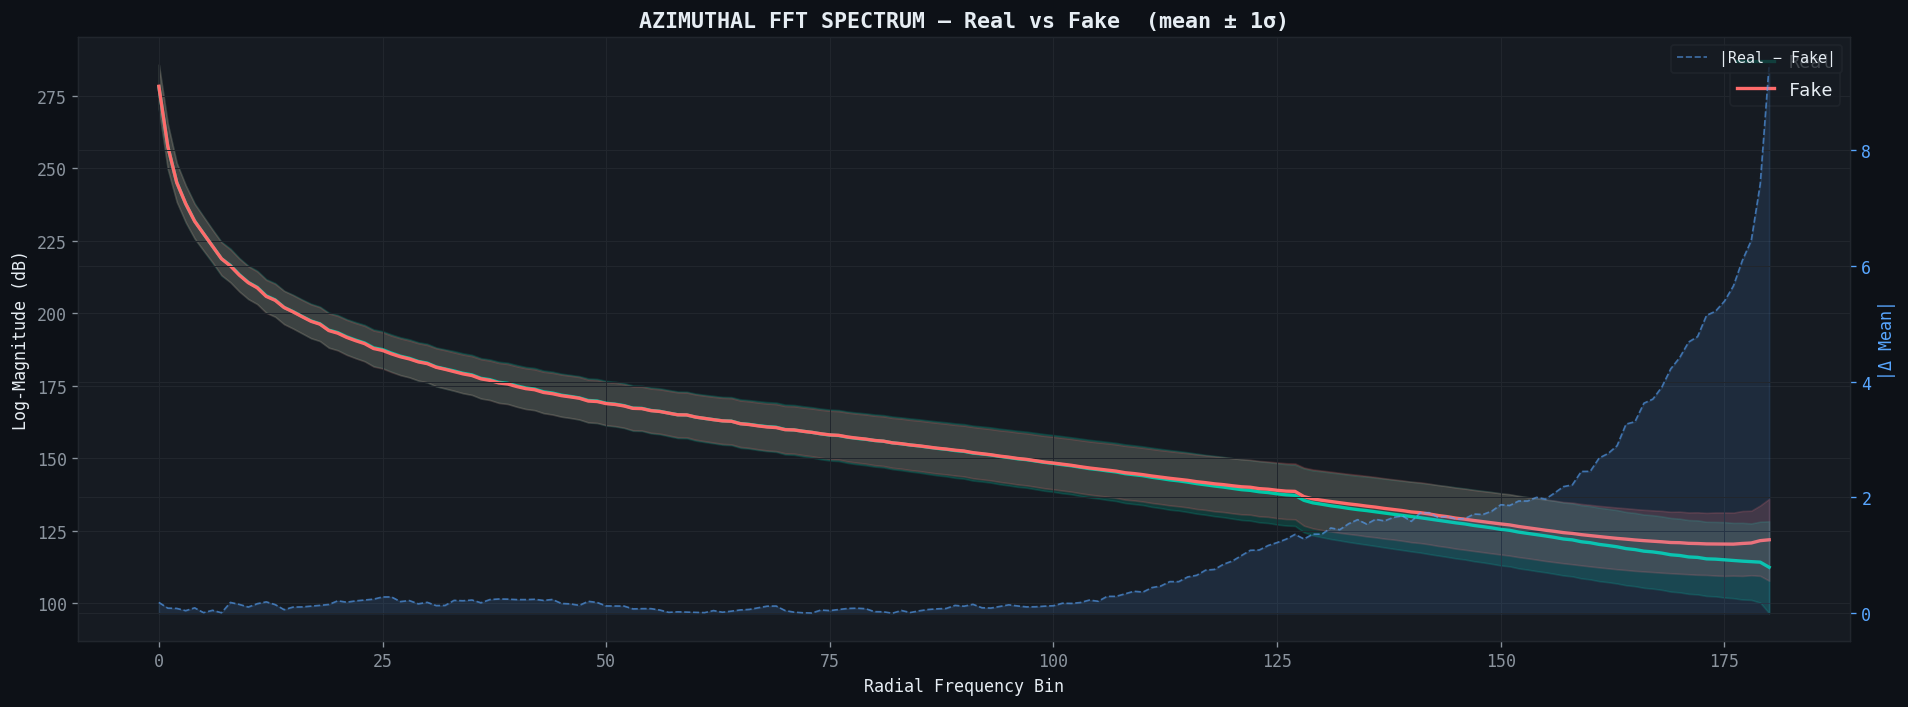

✓  MediaLab\plots\05_azimuthal_fft.png


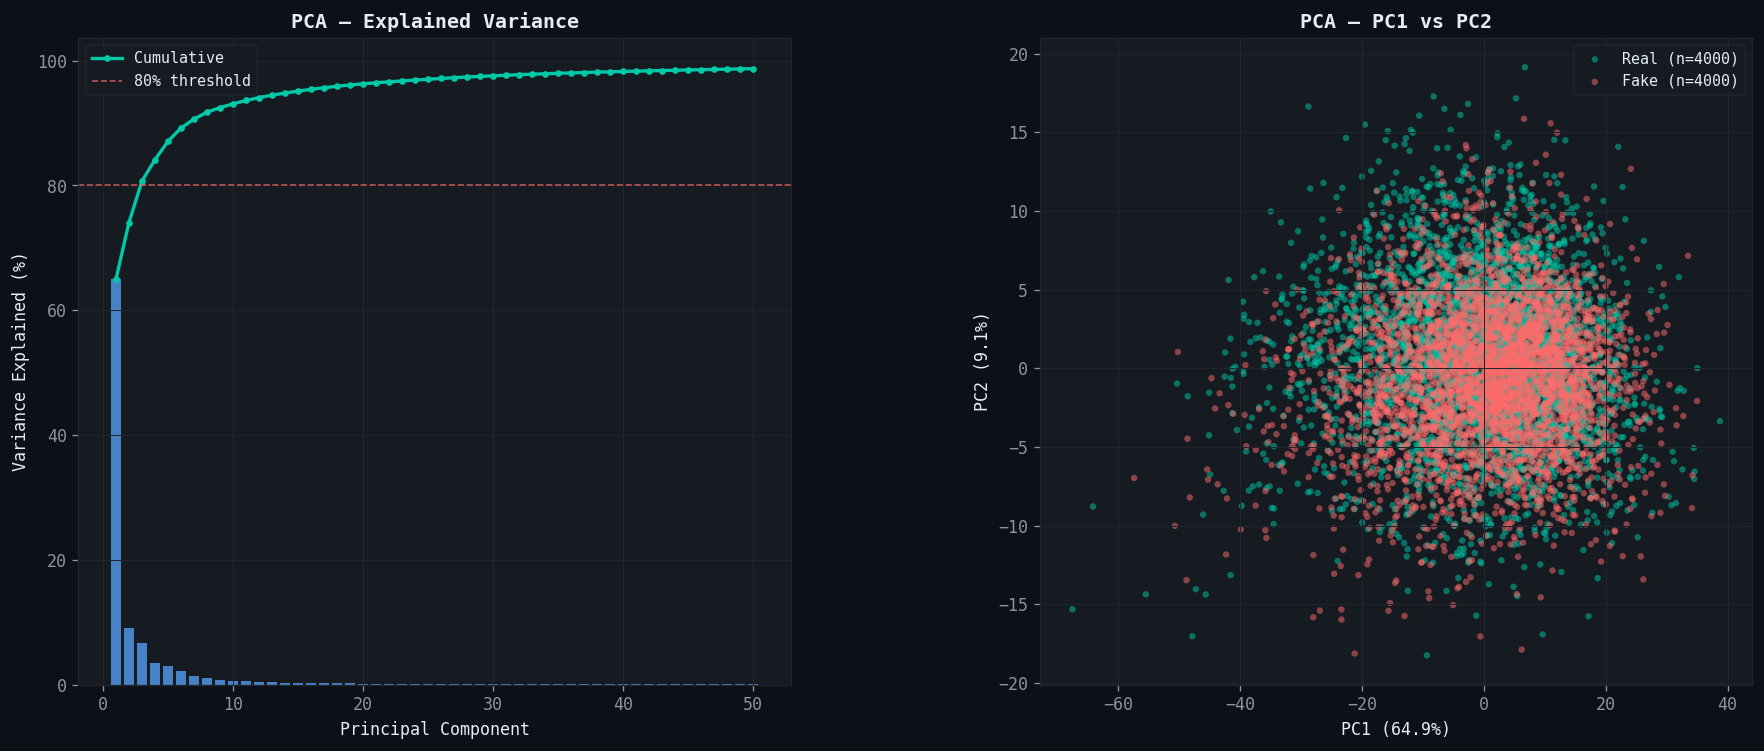

✓  MediaLab\plots\06_pca_variance.png
  Running t-SNE (may take ~1–2 min) …


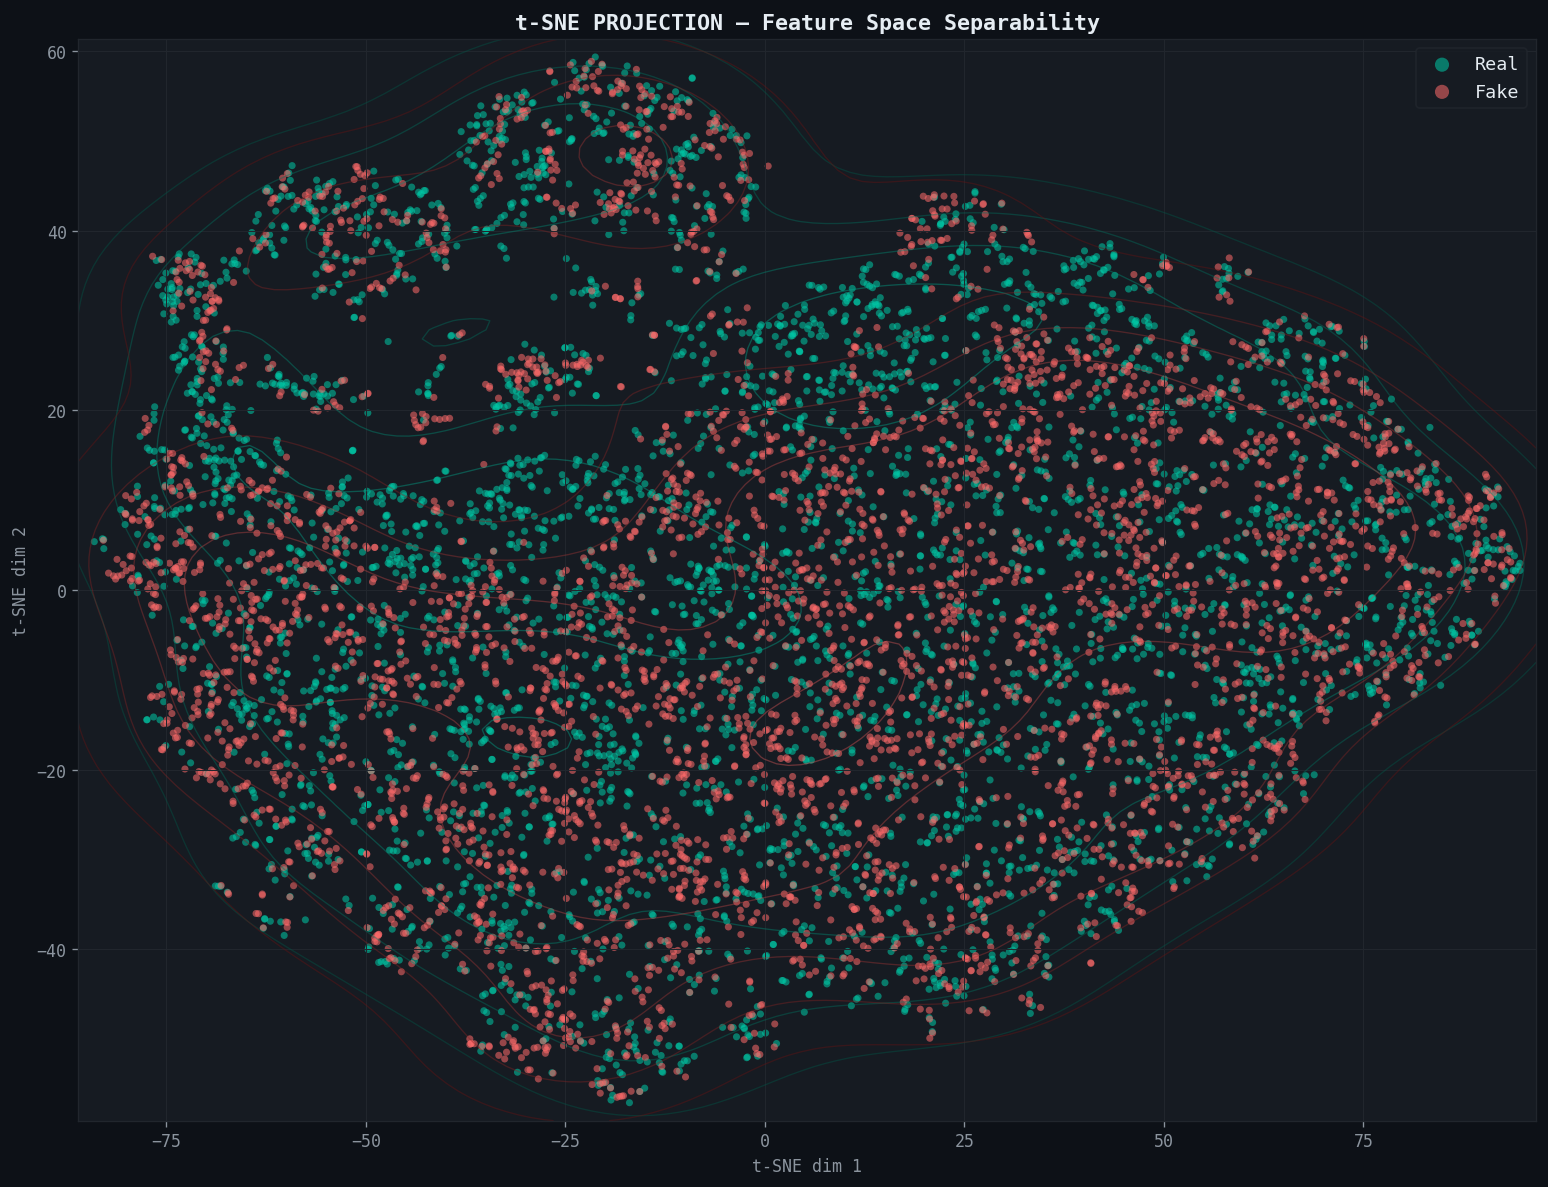

✓  MediaLab\plots\07_tsne_projection.png
  Training RF for feature importance …


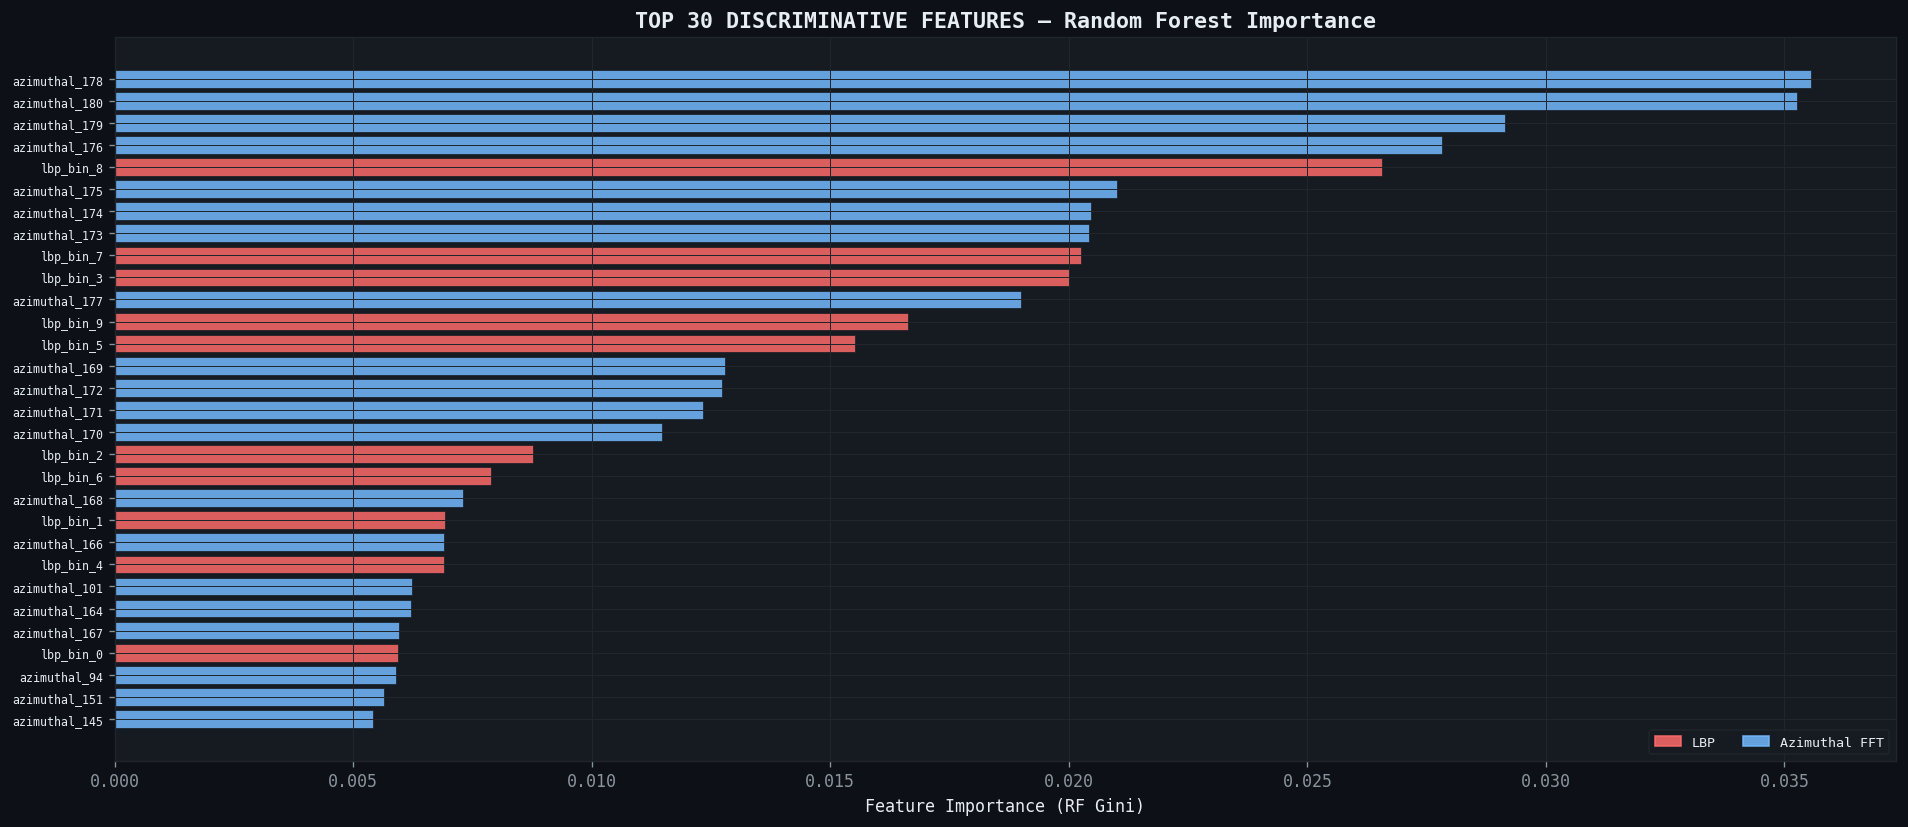

✓  MediaLab\plots\08_feature_importance.png


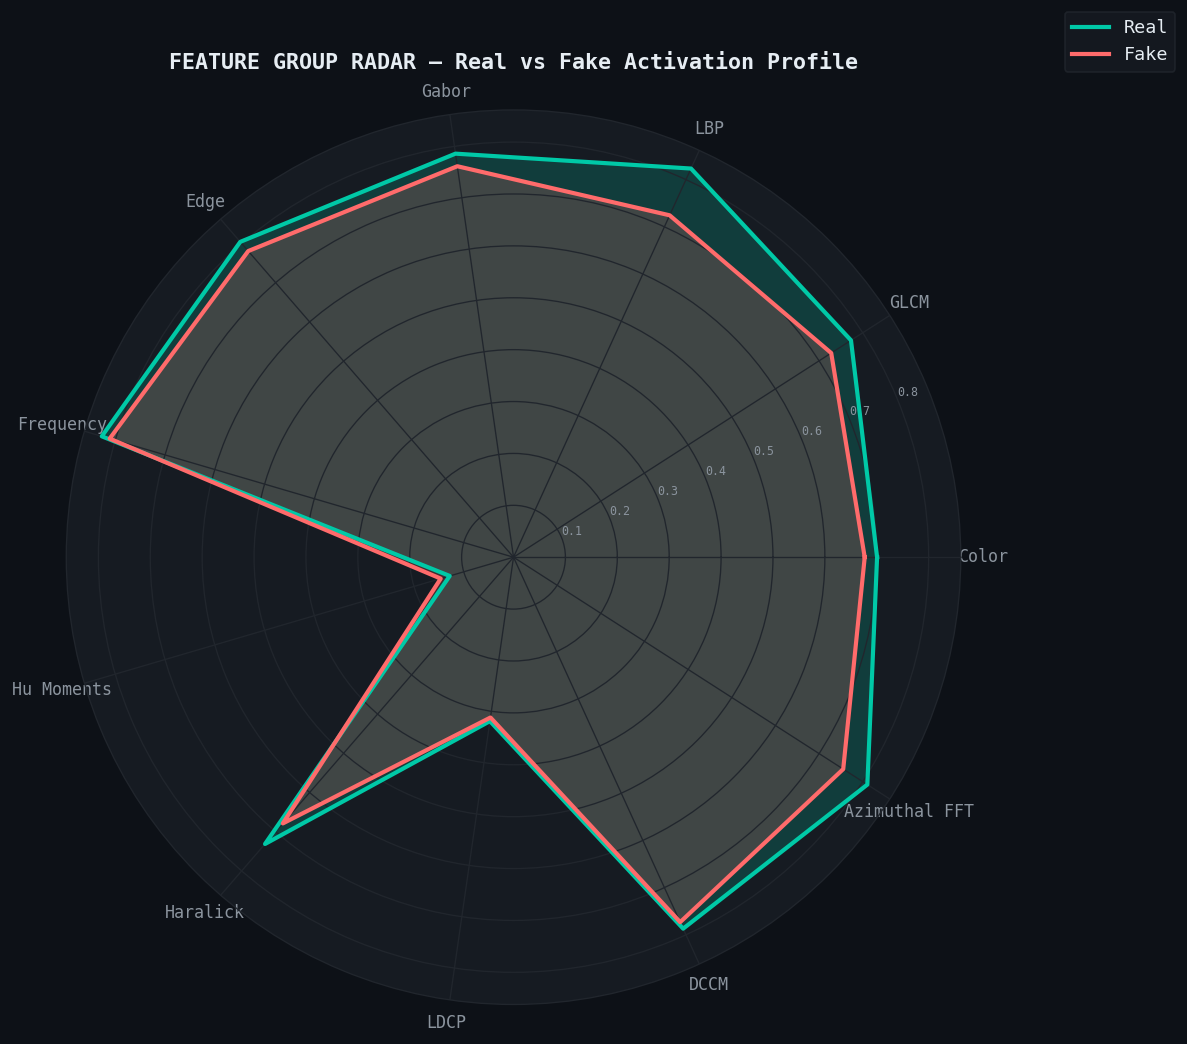

✓  MediaLab\plots\09_radar.png

✓ All plots complete.


In [26]:
print(f"Generating all plots → {OUT_DIR}\n")

plot_class_distributions(X, y, OUT_DIR / "plots" / "01_class_distributions.png")
plot_boxplots            (X, y, OUT_DIR / "plots" / "02_top_features_boxplot.png")
plot_correlation_heatmap (X, y, OUT_DIR / "plots" / "03_correlation_heatmap.png")
plot_feature_group_means (X, y, OUT_DIR / "plots" / "04_feature_group_means.png")
plot_azimuthal_fft       (X, y, OUT_DIR / "plots" / "05_azimuthal_fft.png")
plot_pca_variance        (X, y, OUT_DIR / "plots" / "06_pca_variance.png")
plot_tsne                (X, y, OUT_DIR / "plots" / "07_tsne_projection.png")
plot_feature_importance  (X, y, OUT_DIR / "plots" / "08_feature_importance.png")
plot_radar               (X, y, OUT_DIR / "plots" / "09_radar.png")

print("\n✓ All plots complete.")